# [LAB-10] 7. [PBT] Titanic Suvial
## # 01. 준비작업
### 라이브러리 참조

In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *
from IPython.display import display, Markdown

from pandas import DataFrame

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.29


### 2. 데이터 가져오기

In [3]:
origin = load_data("titanic")
origin

📚 타이타닉호 침몰은 역사상 가장 악명 높은 난파 사고 중 하나입니다. 1912년 4월 15일, 첫 항해 중이던 타이타닉호는 빙산과 충돌하여 침몰했습니다. 당시 배에는 모든 승객과 승무원을 태울 수 있는 구명보트가 충분하지 않아 2,224명의 승객과 승무원 중 1,502명이 목숨을 잃었습니다. 생존에는 어느 정도 운이 작용했지만, 일부 집단은 다른 집단보다 생존 가능성이 더 높았던 것으로 보입니다. 이번 과제에서는 승객 데이터(예: 이름, 나이, 성별, 사회경제적 계층 등)를 사용하여 `어떤 유형의 사람들이 생존할 가능성이 더 높았을까?`라는 질문에 답하는 예측 모델을 구축해야 합니다. (출처: https://www.kaggle.com/datasets/yasserh/titanic-dataset)

변수명       설명
-----------  -------------------------------------------------------
PassengerId  탑승객의 ID(인덱스와 같은 개념)
Survived     생존유무(0은 사망 1은 생존)
Pclass       객실의 등급(1=1등급, 2=2등급, 3=3등급)
Name         이름
Sex          성별
SibSp        동승한 형제 혹은 배우자의 수
Parch        동승한 자녀 혹은 부모의 수
Ticket       티켓번호
Fare         요금
Cabin        선실
Embarked     탑승지 (C = Cherbourg, Q = Queenstown, S = Southampton)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.050,NaN,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.000,0,0,PC 17758,108.900,C105,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.500,0,0,SOTON/O.Q. 3101262,7.250,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.050,NaN,S


### 3. 컬럼 의미를 정리한 딕셔너리

In [4]:
column_means = {
    'PassengerID': '탑승객 식별자',
    'Survived' : '생존 여부 (0=사망, 1=생존)',
    'Pclass' : '객실 등급(1=1등급, 2=2등급, 3=3등급)',
    'Name': '이름',
    'Sex': '성별',
    'Age': '나이',
    'SibSp': '동승한 형제, 배우자 수',
    'Parch': '동승한 부모, 자녀 수',
    'Ticket': '티켓 번호',
    'Fare': '요금',
    'Cabin': '선실 번호',
    'Embarked': '탑승 항구(C=Cherbourg, Q=Queenstown, S=Southanpton)'
}

## #02. 데이터 품질점검
### 1. 자료형 확인

In [5]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(2), int64(5), object(1), str(4)
memory usage: 166.2+ KB


### 2. 데이터 중복 점검

In [6]:
df0 = my_qtcheck.check_duplicates(origin, drop=True)

중복된 행의 수: 0


### 3. 불필요한 컬럼 제거와 자료형 변환
- 분석 대상이 아닌 컬럼을 걷어낸다. 네 개를 각각 다른 이유로 제거한다.
    - PassengerId : 행마다 값이 모두 다른 식별자다. 숫자로 저장되어 있어 그대로 두면 연속형 독립변수로 잘못 투입된다.
    - Name : 1309개가 거의 모두 다른 자유 텍스트다. 그대로는 변수가 될 수 없다.
    - Ticket : 형식이 제각각인 문자열 식별자다.
    - Cabin : 결측이 1,014건(77.5%)이다. 채울 근거가 없는 수준이므로 컬럼째 제거한다.
- 남은 컬럼중 'Survived', 'Pclass', 'Sex', 'Embarked'를 명목형(category)으로 변환
    - Survived는 종속변수이고, Pclass는 1,2,3이라는 숫자로 저장되어 있지만 3등급은 1등급의 3배가 아니므로 연속형으로 두면 안된다.

In [8]:
# 원본에서 제거된 중복 데이터가 없으므로 계속 원본 사용
df0 = origin.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df1 = my_qtcheck.set_type(df0, as_category=['Survived', 'Pclass', 'Sex', 'Embarked'])

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  1309 non-null   category
 1   Pclass    1309 non-null   category
 2   Sex       1309 non-null   category
 3   Age       1046 non-null   float64 
 4   SibSp     1309 non-null   int64   
 5   Parch     1309 non-null   int64   
 6   Fare      1308 non-null   float64 
 7   Embarked  1307 non-null   category
dtypes: category(4), float64(2), int64(2)
memory usage: 46.2 KB


### 4. 결측치 점검

In [9]:
my_qtcheck.check_missing_values(df1)

,Missing Count,Missing Ratio (%)
Survived,0,0.000
Pclass,0,0.000
Sex,0,0.000
Age,263,20.092
SibSp,0,0.000
Parch,0,0.000
Fare,1,0.076
Embarked,2,0.153


### 5. 결측치 대체
- 로지스틱 회귀는 결측치가 하나라도 있으면 적합되지 않는다. 모델링 전에 반드시 채워야 한다.
- 컬럼의 성격에 따라 대체 방법을 다르게 쓴다.
    - 사전에 기술 통계량 확인 필요

In [10]:
df2= my_prep.replace_missing(df1, columns=['Age', 'Fare'], method='median')
df3= my_prep.replace_missing(df2, columns=['Embarked'], method='mode')

# 결측치가 모두 처리되었는지 확인
my_qtcheck.check_missing_values(df3)

결측치 처리 방식: 'median'
컬럼                     결측치                 대체값
--------------------------------------------
Age          263개(20.1%)              28.0
Fare            1개(0.1%)           14.4542
결측치 처리 방식: 'mode'
컬럼                     결측치                 대체값
--------------------------------------------
Embarked        2개(0.2%)                 S


,Missing Count,Missing Ratio (%)
Survived,0,0.000
Pclass,0,0.000
Sex,0,0.000
Age,0,0.000
SibSp,0,0.000
Parch,0,0.000
Fare,0,0.000
Embarked,0,0.000


- 한계 기록
    - Age의 20.1%를 하나의 값으로 채우는 것은 가볍게 볼 일이 아니다. 나이 분포에 중앙값 자리의 인공적인 봉우리가 생기고, 나이의 효과가 실제보다 약하게 추정된다. 이 한계는 반드시 기록해 두어야 한다.

### 6. 파생변수 생성(1) - 동승자 수 계산

In [33]:
# 결측처리까지 끝난 데이터에 파생변수를 더한다(df3는 그대로 보존)
derived = df3.copy()

# 새로운 파생변수 생성
derived['FamilySize'] = derived['SibSp'] + derived['Parch'] + 1

# 컬럼 의미 갱신
column_means['FamilySize'] = '동승 가족 수 (SibSp + Parch + 본인)'

# 결과 확인
derived.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,male,22.000,1,0,7.250,S,2
1,1,1,female,38.000,1,0,71.283,C,2
2,1,3,female,26.000,0,0,7.925,S,1
3,1,1,female,35.000,1,0,53.100,S,2
4,0,3,male,35.000,0,0,8.050,S,1


### 7. 신분 파생 변수 추가(1) - 이름에서 호칭 분리
- 타이타닉의 이름은 '성, 호칭. 이름' 형식으로 통일되어 있다.
- 쉼표와 마침표 사이를 뽑으면 호칭이 나온다. 정규식 ',\s*([^\.]+)\.'이 그 일을 한다.
- 뽑아 쓰는 대상은 origin['Name']이다.
    - 작업본에서는 이미 지운 컬럼이지만 원본에는 남아있다.

In [12]:
# -- 1) 이름에서 호칭 추출 : "성, 호칭. 이름" 형식이므로 쉼표와 마침표 사이를 뽑는다.
title_raw = origin['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)
title_raw = title_raw.str.strip()

display(Markdown('**원본 호칭 (통합 전 18종)**'))
display(title_raw.value_counts().rename('빈도').to_frame().T)

**원본 호칭 (통합 전 18종)**

Name,Mr,Miss,Mrs,Master,Rev,Dr,Col,Ms,Major,Mlle,Don,Mme,Lady,Sir,Capt,the Countess,Jonkheer,Dona
빈도,757,260,197,61,8,8,4,2,2,2,1,1,1,1,1,1,1,1


### 8. 신분 파생 변수 추가(2) - 의미별 호칭 정의 -> 도메인 지식 필요

In [13]:
# ── 18종의 호칭을 의미가 같은 것끼리 묶어 5종으로 통합한다
#    (도메인 지식이 필요한 부분)
title_map = {
    # 성인 남성 ─ Don(스페인)·Sir(영국)·Jonkheer(네덜란드)는 남성 귀족 경칭
    "Mr": "Mr", "Don": "Mr", "Sir": "Mr", "Jonkheer": "Mr",
    # 미혼 여성 ─ Mlle(프랑스)=Miss, Ms=혼인 여부를 밝히지 않는 호칭
    "Miss": "Miss", "Mlle": "Miss", "Ms": "Miss",
    # 기혼 여성 ─ Mme(프랑스)·Dona(스페인)=Mrs, Lady·the Countess는 여성 귀족 경칭
    "Mrs": "Mrs", "Mme": "Mrs", "Dona": "Mrs", "Lady": "Mrs", "the Countess": "Mrs",
    # 남자아이
    "Master": "Master",
    # 전문직·군인·성직자 ─ 이름에 직위가 드러난 사람들
    "Dr": "Officer", "Rev": "Officer", "Col": "Officer", "Major": "Officer", "Capt": "Officer"
}

### 9. 신분 파생 변수 추가(3) - 호칭 파생변수 추가 -> 신분을 의미

In [14]:
# ── Title 변수 추가 (origin 과 인덱스가 같으므로 그대로 붙는다)
derived["Title"] = title_raw.map(title_map)

# ── 매핑 누락 점검 : 결측이 1건이라도 있으면 title_map 에 빠진 호칭이 있다는 뜻이다
print("Title 매핑 누락 :", derived["Title"].isna().sum(), "건\n")

# ── 문자열이므로 명목형으로 선언한다. 그대로 두면 더미 인코딩 대상이 되지 않는다
derived = my_qtcheck.set_type(derived, as_category=["Title"])

# ── 컬럼 의미 사전도 함께 갱신한다 (이후 EDA 반복문이 이 사전을 참조한다)
column_means["Title"] = "이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)"

display(origin[["Name"]].join(derived[["Title", "SibSp", "Parch", "FamilySize"]]).head())
display(derived["Title"].value_counts().rename("빈도").to_frame().T)

Title 매핑 누락 : 0 건

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    1309 non-null   category
 1   Pclass      1309 non-null   category
 2   Sex         1309 non-null   category
 3   Age         1309 non-null   float64 
 4   SibSp       1309 non-null   int64   
 5   Parch       1309 non-null   int64   
 6   Fare        1309 non-null   float64 
 7   Embarked    1309 non-null   category
 8   FamilySize  1309 non-null   int64   
 9   Title       1309 non-null   category
dtypes: category(5), float64(2), int64(3)
memory usage: 57.9 KB


,Name,Title,SibSp,Parch,FamilySize
0,"Braund, Mr. Owen Harris",Mr,1,0,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",Mrs,1,0,2
2,"Heikkinen, Miss. Laina",Miss,0,0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,1,0,2
4,"Allen, Mr. William Henry",Mr,0,0,1


Title,Mr,Miss,Mrs,Master,Officer
빈도,760,264,201,61,23


### 10. 생성된 신분 파생 변수의 분포 확인

In [16]:
# -- 호칭이 정말 '신분'을 담고 있는지 확인한다.
from pandas import crosstab


display(Markdown('**호칭별 성별 분포**'))
display(crosstab(derived['Title'], derived['Sex']))

# 나이는 결측을 채우기 전인 origin 기준으로 본다.
# -> derived의 Age는 중앙값 28세로 채워져 있어 호칭별 분호가 왜곡된다.
display(Markdown('**호칭별 나이 요약 (결측 대체 전 "origin" 기준)**'))
display(origin.assign(Title = derived['Title'])
        .groupby('Title', observed=True)['Age']
        .agg(['count', 'median', 'min', 'max']).T)

**호칭별 성별 분포**

Sex,female,male
Title,,
Master,0,61
Miss,264,0
Mr,0,760
Mrs,201,0
Officer,1,22


**호칭별 나이 요약 (결측 대체 전 "origin" 기준)**

Title,Master,Miss,Mr,Mrs,Officer
count,53.000,213.000,584.000,174.000,22.000
median,4.000,22.000,29.000,35.500,49.500
min,0.330,0.170,11.000,14.000,23.000
max,14.500,63.000,80.000,76.000,70.000


### 11. 명목형 변수의 기술 통계량0

In [17]:
cat_desc = my_qtcheck.categorical_summary(derived, value_counts=False)
cat_desc

,Survived,Pclass,Sex,Embarked,Title
count,1309,1309,1309,1309,1309
unique,2,3,2,3,5
top,0,3,male,S,Mr
freq,815,709,843,916,760


### 12. 연속형 기술 통계량
- 여기서 생성한 기술 통계량 표가 단변량 분석에서 활용되기 때문에 여기서는 인사이트 발굴 없이 통계량 표만 확인하고 넘어가도 된다.

In [19]:
num_desc = my_qtcheck.numerical_summary(derived)
num_desc.T

,Age,SibSp,Parch,Fare,FamilySize
count,1309.000,1309.000,1309.000,1309.000,1309.000
mean,29.503,0.499,0.385,33.281,1.884
std,12.905,1.042,0.866,51.741,1.584
min,0.170,0.000,0.000,0.000,1.000
25%,22.000,0.000,0.000,7.896,1.000
50%,28.000,0.000,0.000,14.454,1.000
75%,35.000,1.000,0.000,31.275,2.000
max,80.000,8.000,9.000,512.329,11.000
rel_diff,0.054,inf,inf,1.303,0.884
rdiff_flag,similar,large_diff,large_diff,large_diff,large_diff


## #03. 변수 유형 분류와 EDA 범위
### 1. 변수 유형 분류

In [23]:
target = 'Survived'  # 종속변수
target_is_continuous = False  # 종속변수 연속형 여부 --> 로지스틱이므로 False
nominal_cols = my_qtcheck.get_categorical_column_names(derived)  # 명목형 변수
continuous_cols = my_qtcheck.get_number_column_names(derived)    # 연속형 변수

if target_is_continuous:
    continuous_cols.remove(target)  # 연속형 변수 이름에서 종속변수 항목 제거
else:
    nominal_cols.remove(target)     # 명목형 변수 이름에서 종속변수 항목 제거

print("종속변수 : ", target)
print("종속변수 유형 : " + ('연속형' if target_is_continuous else "명목형"))
print('명목형 : ', nominal_cols)
print('연속형 :',continuous_cols)

종속변수 :  Survived
종속변수 유형 : 명목형
명목형 :  ['Pclass', 'Sex', 'Embarked', 'Title']
연속형 : ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']


### 2. 범주 순서 지정(서열척도, 기준범주)

In [25]:
# 1) 서열척도를 적용할 변수와 순서를 정의한다(낮은 등급 -> 높은 등급)
ordinal_map = {
    'Pclass' :[3,2,1]   # 3등급 < 2등급 < 1등급
}

# 2) 서열은 없지만 더미변수의 기준(reference) 범주를 지정하기 위해 순서만 재배치할 변수
# -> 맨 앞에 둔 범주가 drop_first로 빠지면서 기준이 된다
reference_map = {
    "Title" : ['Mr', 'Officer', 'Master', 'Miss', 'Mrs']  # 기준 : Mr(성인 남성)
}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
df = derived.copy()

for col, order in ordinal_map.items():
    if col in df.columns:
        print(f"'{col}' 컬럼 순서 재지정 (서열척도)   : {order}")
        df[col] = df[col].cat.reorder_categories(order, ordered = True)

for col, order in reference_map.items():
    if col in df.columns:
        print(f"'{col}' 컬럼 순서 재지정 (기준 범주용)   : {order}")
        # ordered = False -> 순서만 바꿀 뿐 서열척도로 선언하지는 않는다.
        df[col] = df[col].cat.reorder_categories(order, ordered = False)

'Pclass' 컬럼 순서 재지정 (서열척도)   : [3, 2, 1]
'Title' 컬럼 순서 재지정 (기준 범주용)   : ['Mr', 'Officer', 'Master', 'Miss', 'Mrs']


## 연습문제 - 타이타닉 생존율 예측 #01
□ 분석 과정을 실습하고 다음 물음에 답하시오.

- 데이터를 불러왔을 때, 원본 데이터의 관측치(행)는 몇 개인가요? 1309
- 원본 데이터는 몇 개의 컬럼으로 이루어져 있나요? 12
- 원본 12개 컬럼 중 결측치가 하나라도 있는 컬럼은 몇 개인가요? 4
- 결측 비율이 가장 높은 컬럼은 무엇인가요? Cabin
- 원본 상태에서 중복 점검을 수행했을 때, 중복된 행은 몇 개인가요? 0
- 분석 대상이 아닌 컬럼을 제거하고 나면, 남은 데이터는 몇 개의 컬럼이 되나요? 10
- Age의 결측 263건을 채우는 데 사용한 대체값은 얼마인가요? 28.0
- Embarked의 결측 2건을 채우는 데 사용한 값은 무엇인가요? S
- 이름에서 추출한 원본 호칭은 모두 몇 종인가요? 18
- 18종의 호칭을 의미별로 통합한 뒤, Title의 범주는 몇 개가 되나요? 5
- Title의 5개 범주 중 관측치가 가장 적은 것은 무엇인가요? Officer
- Master의 나이 최댓값은 몇 살인가요? 14.5
- 파생변수 두 개를 추가하고 나면, 데이터는 몇 개의 컬럼이 되나요? 10
- 연속형 5종 중 이상치가 가장 많이 섞여 있는 항목은 무엇인가요? Parch
- 연속형 5종 중 분포의 비대칭이 가장 큰(왜도의 절댓값이 가장 큰) 항목은 무엇인가요? Fare
- 종속변수를 제외하고 나면, 명목형 독립변수는 몇 개인가요? 4
- 종속변수를 제외하고 나면, 연속형 독립변수는 몇 개인가요? 5
- 척도 조합표의 아홉 가지 경우 중, 이 데이터에서 실제로 수행되는 분석 기법은 몇 가지인가요? 3
- 서열척도로 순서를 지정한 변수는 무엇인가요? Pclass
- Title의 기준(reference) 범주로 지정한 값은 무엇인가요? Title

## #04. 단변량 분석
### 1. 명목형 종속변수에 대한 단변량 분석

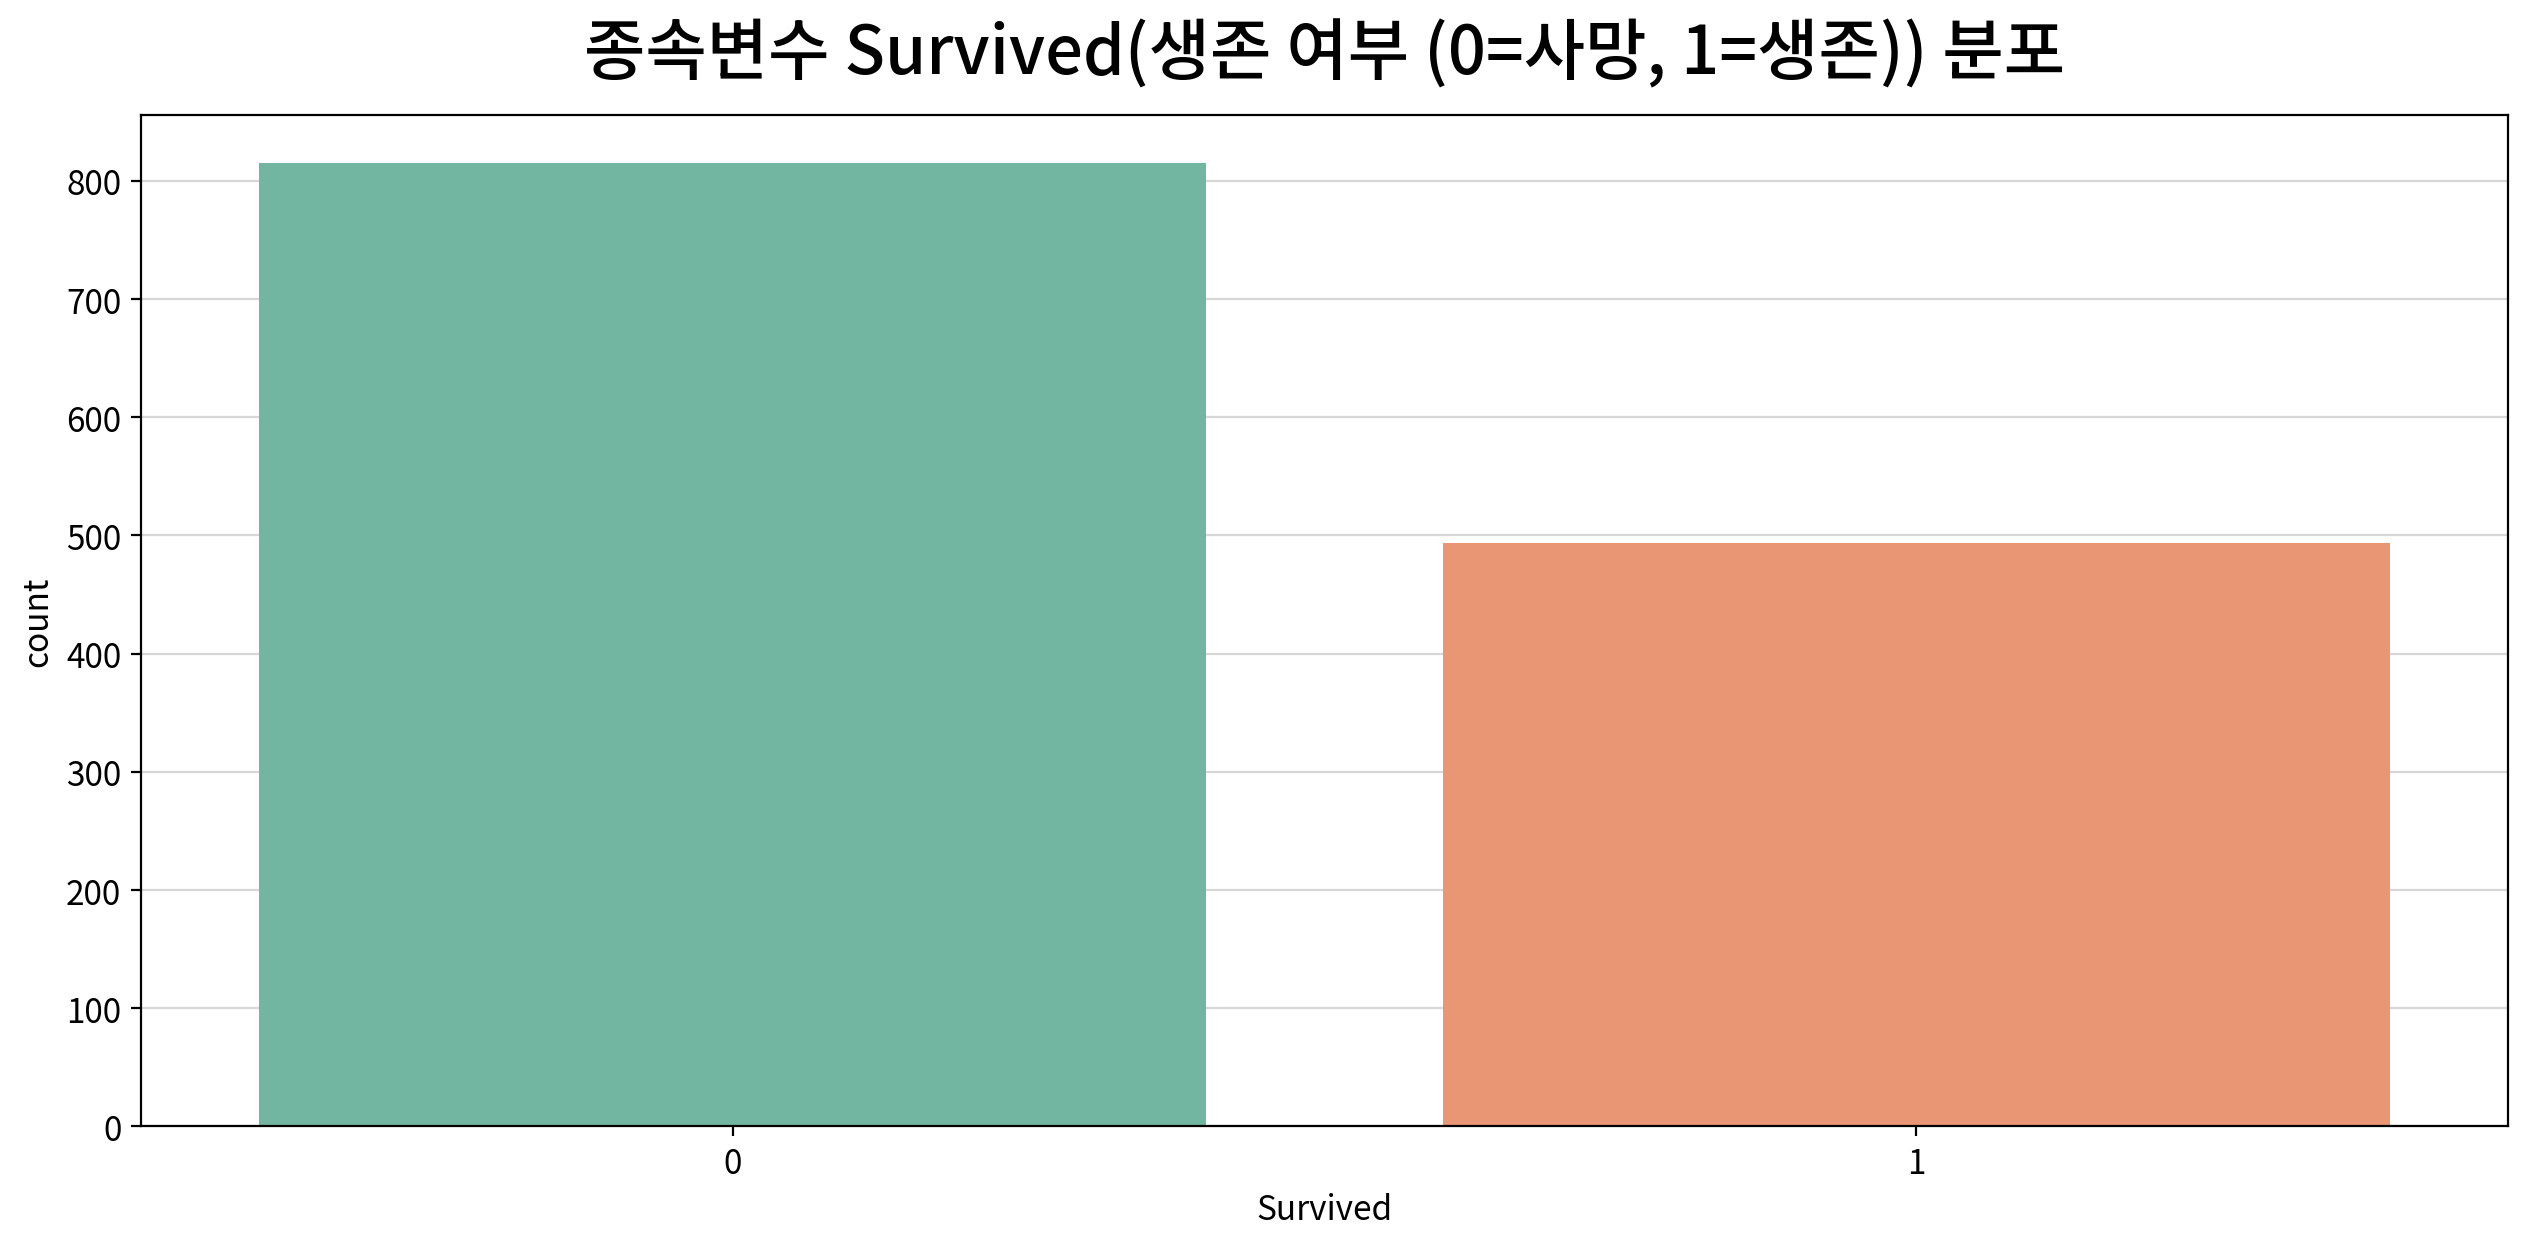

,count,unique,top,freq
Survived,1309,2,0,815


,빈도,비율
Survived,,
0,815,0.623
1,494,0.377


In [27]:
# 명목형 분포는 카운트 플롯으로 처리한다.
my_plot.countplot(data=df, x=target, hue=target, palette='Set2', title=f'종속변수 {target}({column_means[target]}) 분포')

# 명목형 기술 통계량
display(cat_desc[[target]].T)

# 추가적으로 빈도표 생성
freq = df[target].value_counts().rename('빈도').to_frame()
freq['비율'] =df[target].value_counts(normalize=True)
display(freq)

- 정확도의 바닥값(baseline)은 62.3%다. 모두 사망이라고만 답하는 게으른 모형도 62.3%를 맞힌다.
- 즉 정확도 70%짜리 모형은 좋은 모형이 아니다. 바닥값보다 8%p 나은 것에 불과하다. 정확도 하나만 보지 말고 재현도, 정밀도, AUC를 함께 확인해야함

### 2. 명목형 독립변수에 대한 단변량 분석
- 명목형 독립변수도 범주별 빈도의 쏠림을 확인한다.
    - 한 범주에 관측치가 지나치게 적으면 그 더미변수의 계수가 불안정해지기 때문이다.

### ▶ Pclass(객실 등급(1=1등급, 2=2등급, 3=3등급)) 분포

Pclass,3,1,2
빈도,709.000,323.000,277.000
비율,0.542,0.247,0.212


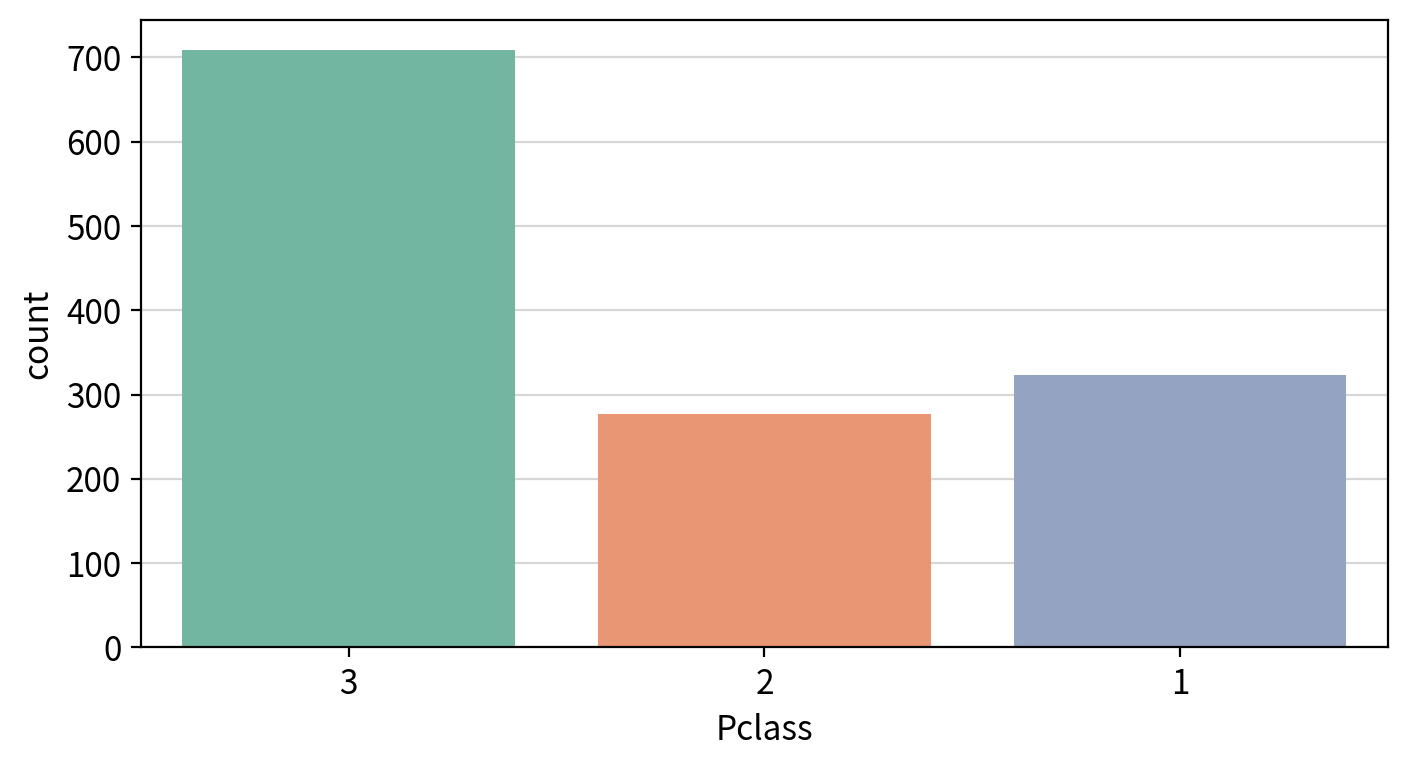

### ▶ Sex(성별) 분포

Sex,male,female
빈도,843.000,466.000
비율,0.644,0.356


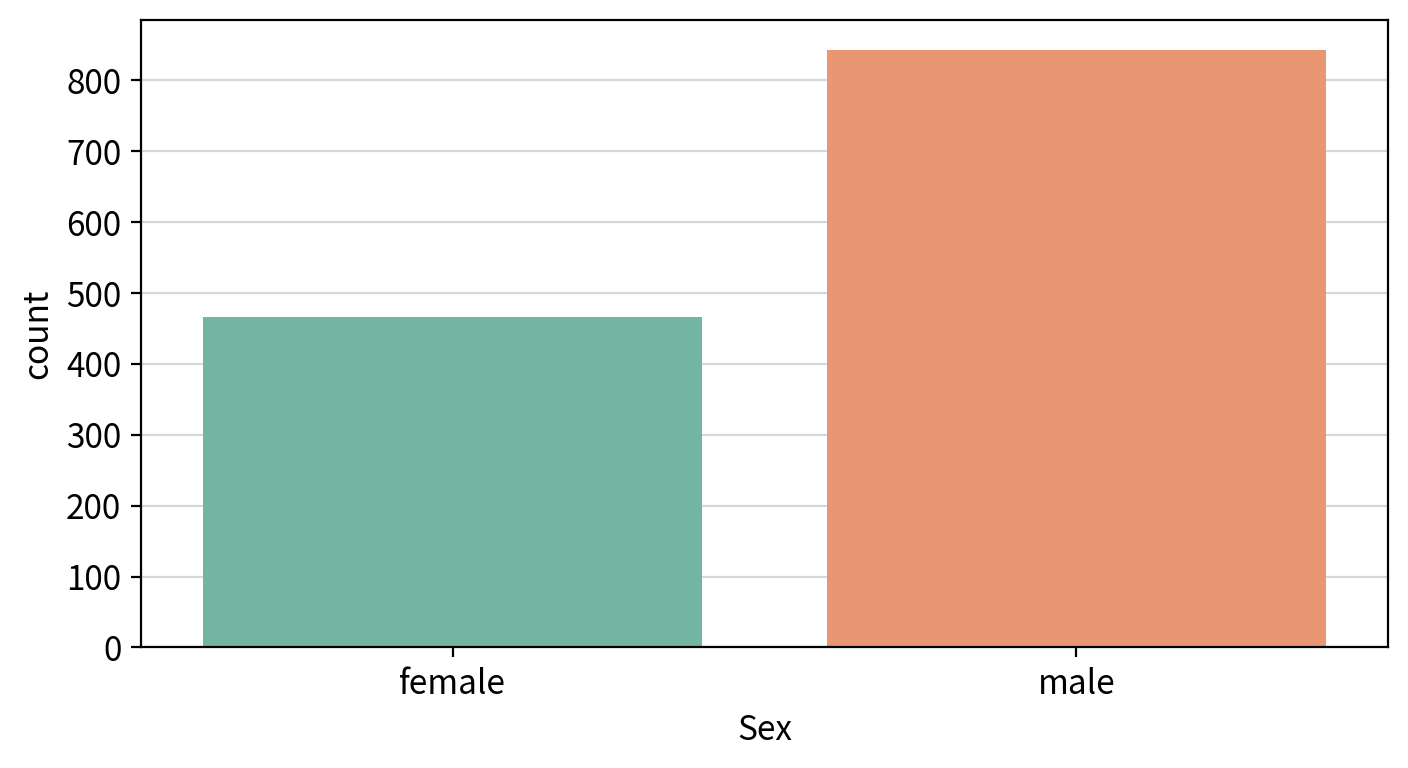

### ▶ Embarked(탑승 항구(C=Cherbourg, Q=Queenstown, S=Southanpton)) 분포

Embarked,S,C,Q
빈도,916.000,270.000,123.000
비율,0.700,0.206,0.094


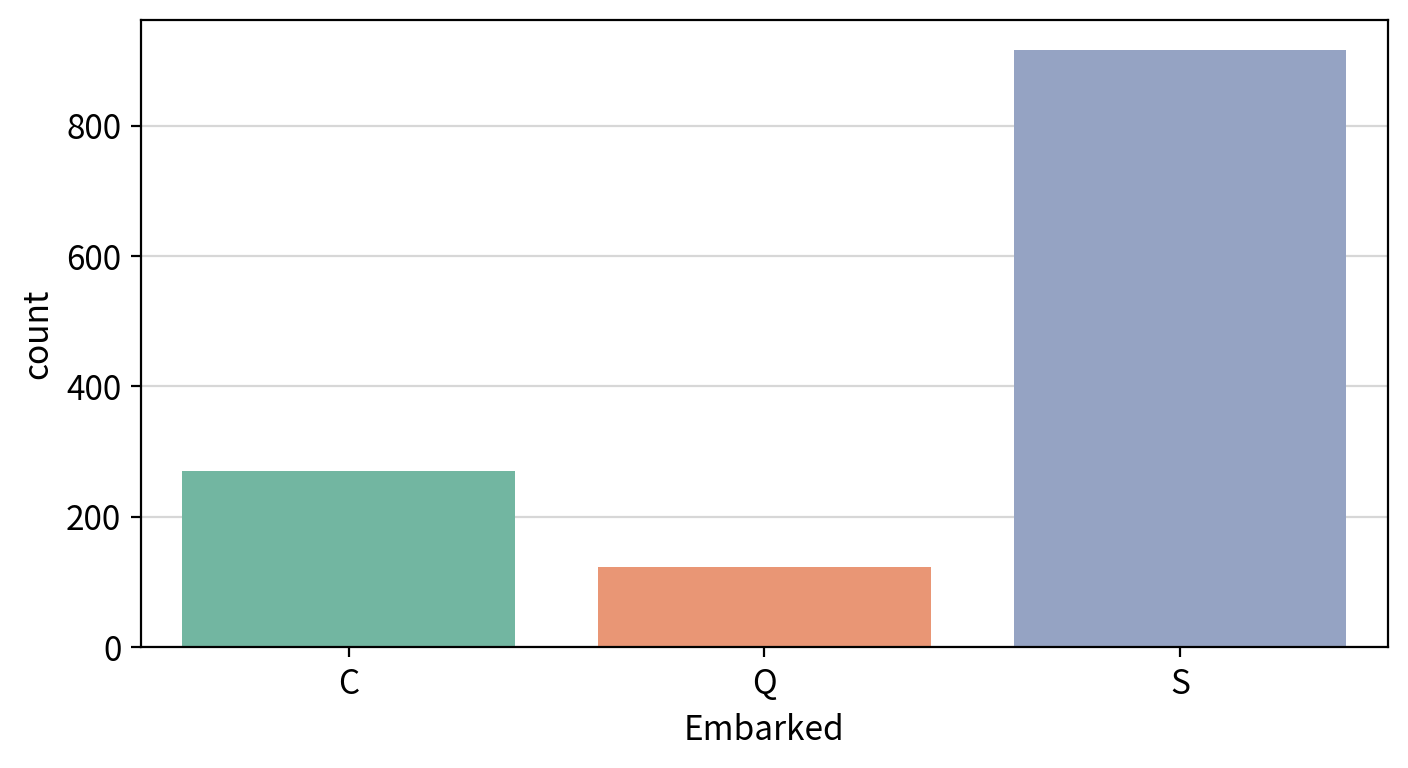

### ▶ Title(이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)) 분포

Title,Mr,Miss,Mrs,Master,Officer
빈도,760.000,264.000,201.000,61.000,23.000
비율,0.581,0.202,0.154,0.047,0.018


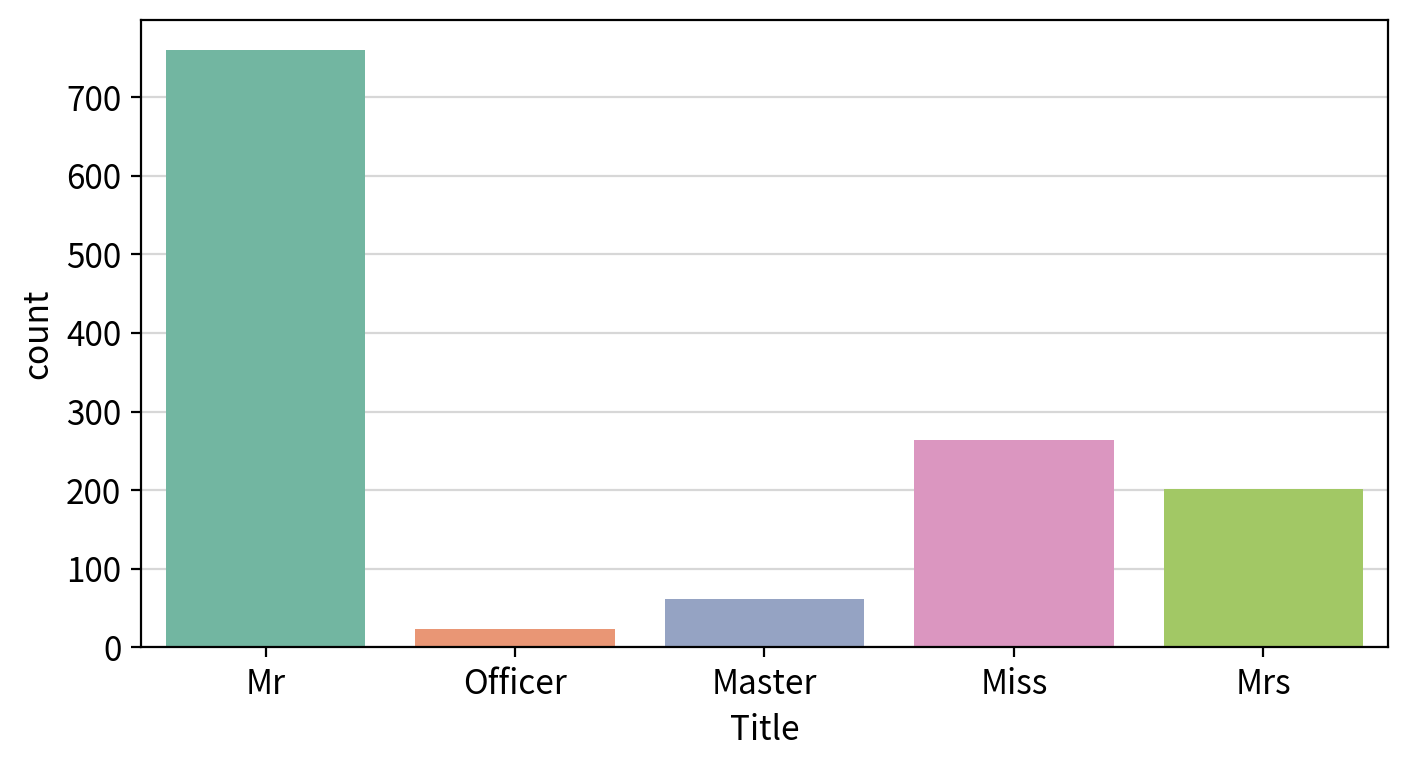

In [31]:
for n in nominal_cols:
    display(Markdown(f'### ▶ {n}({column_means[n]}) 분포'))
    freq = df[n].value_counts().rename('빈도').to_frame()
    freq['비율'] =df[n].value_counts(normalize=True)
    display(freq.T)

    my_plot.countplot(data=df, x=n, hue=n, palette='Set2', width=720, height=400)

### 3. 연속형 독립변수에 대한 단변량 분석

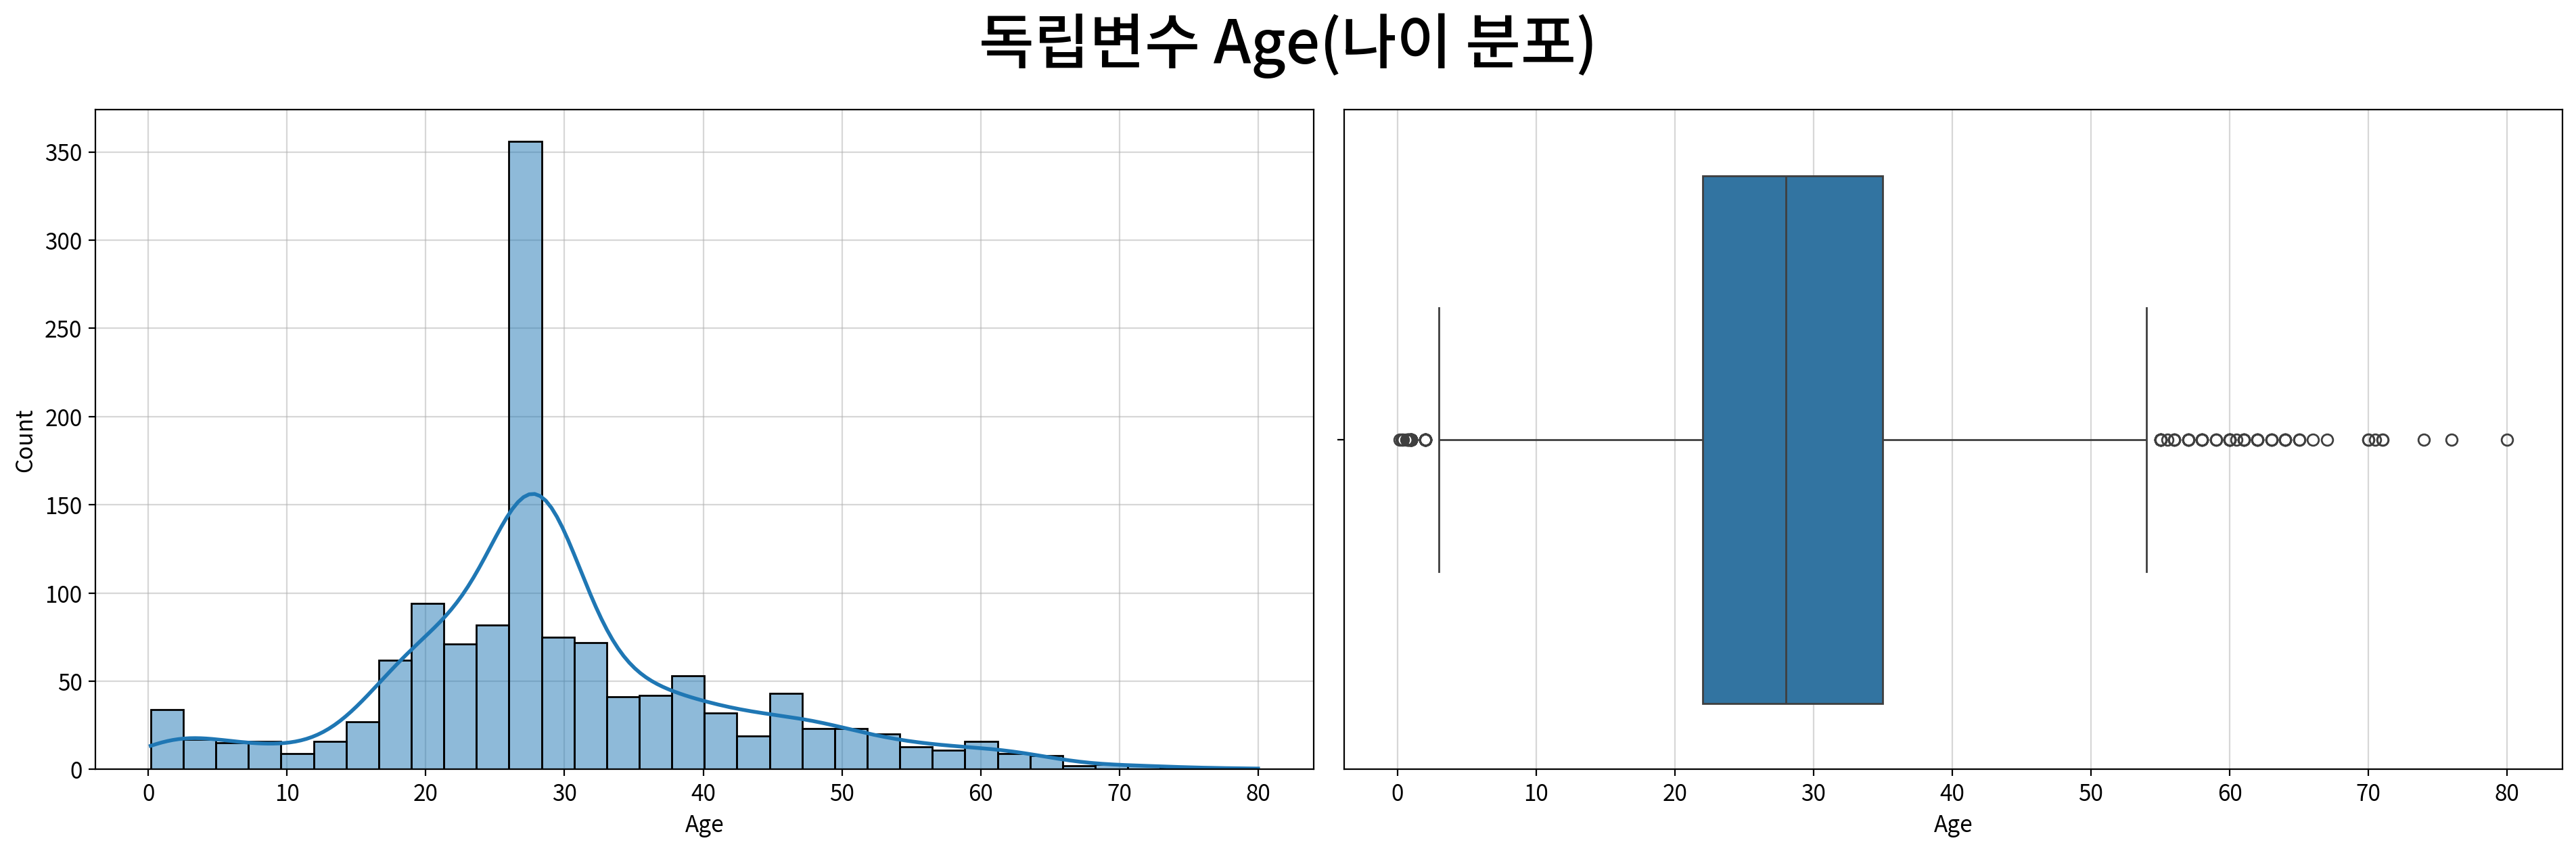

,Age
count,1309.000
mean,29.503
std,12.905
min,0.170
25%,22.000
50%,28.000
75%,35.000
max,80.000
rel_diff,0.054
rdiff_flag,similar


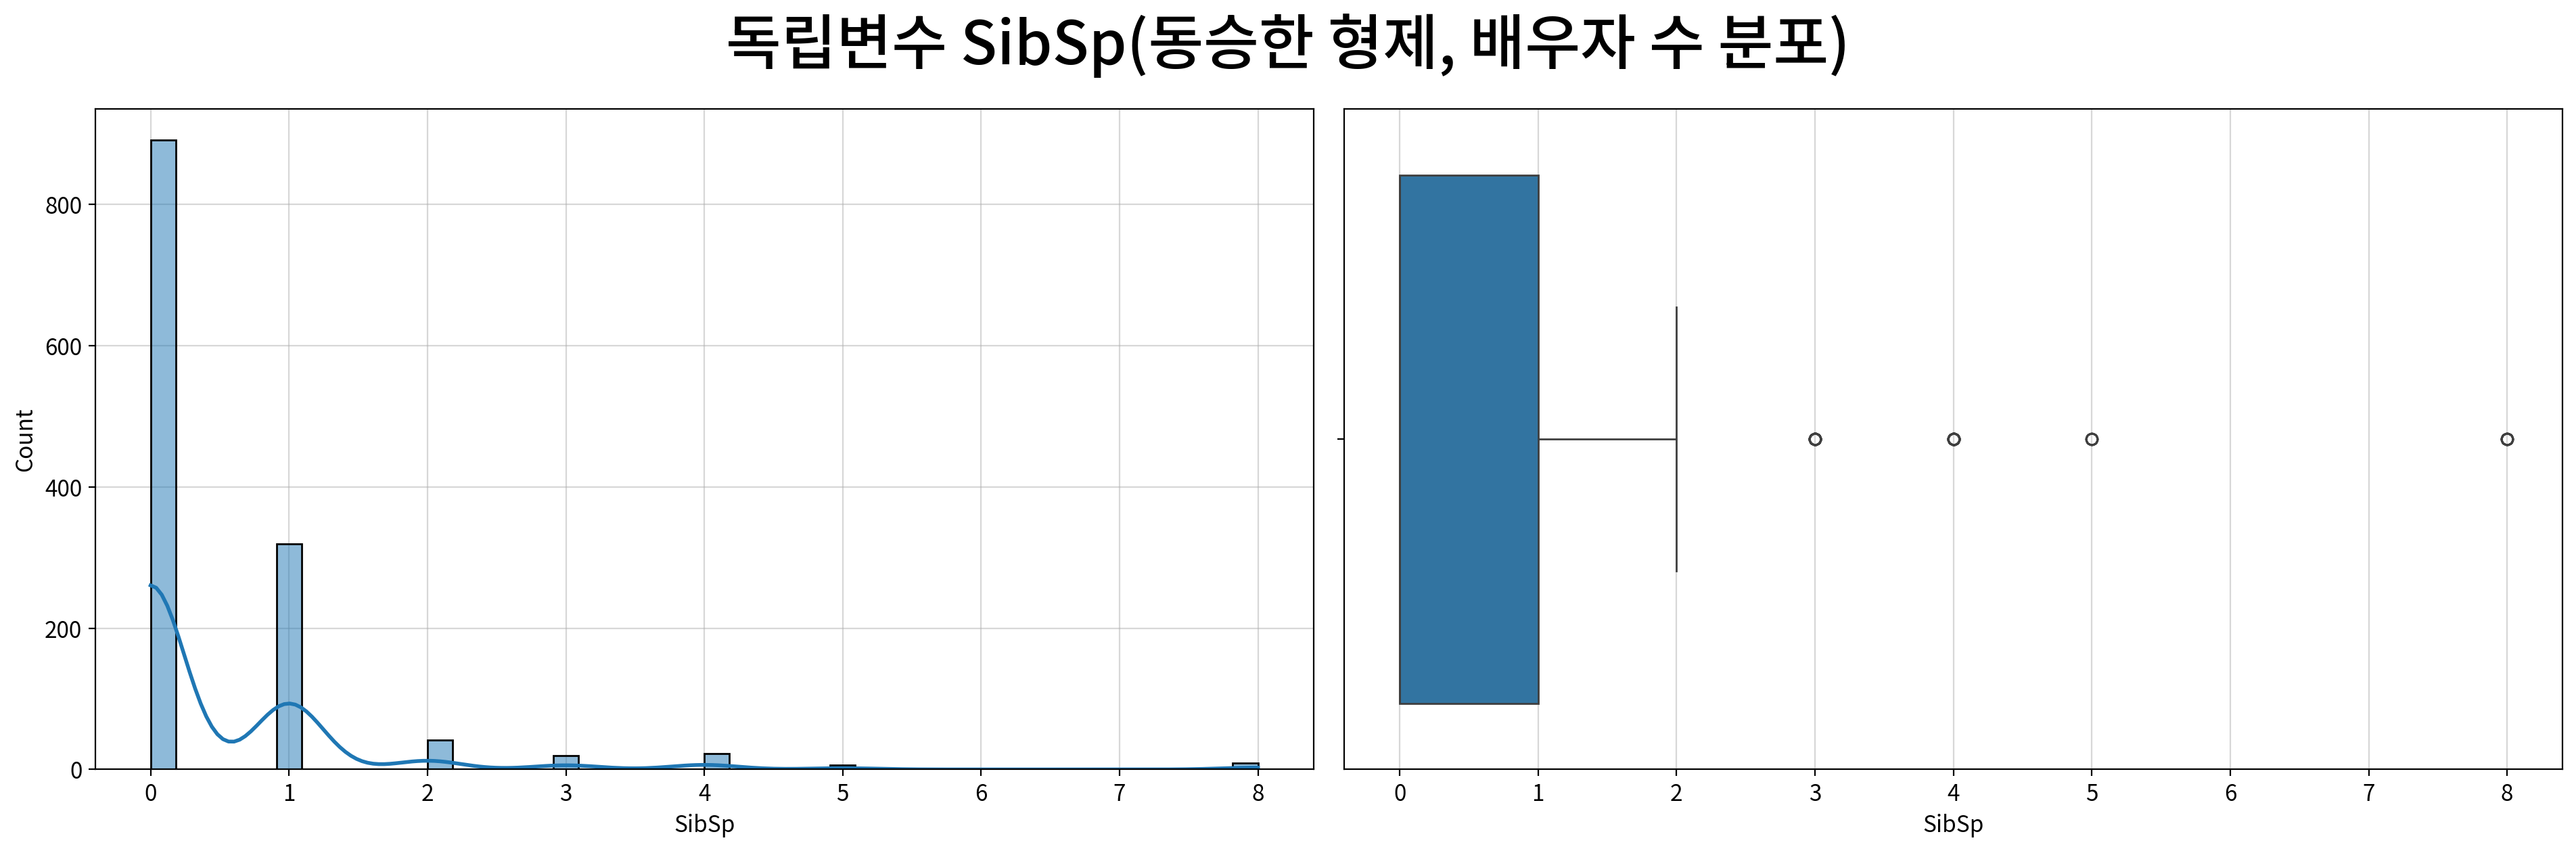

,SibSp
count,1309.000
mean,0.499
std,1.042
min,0.000
25%,0.000
50%,0.000
75%,1.000
max,8.000
rel_diff,inf
rdiff_flag,large_diff


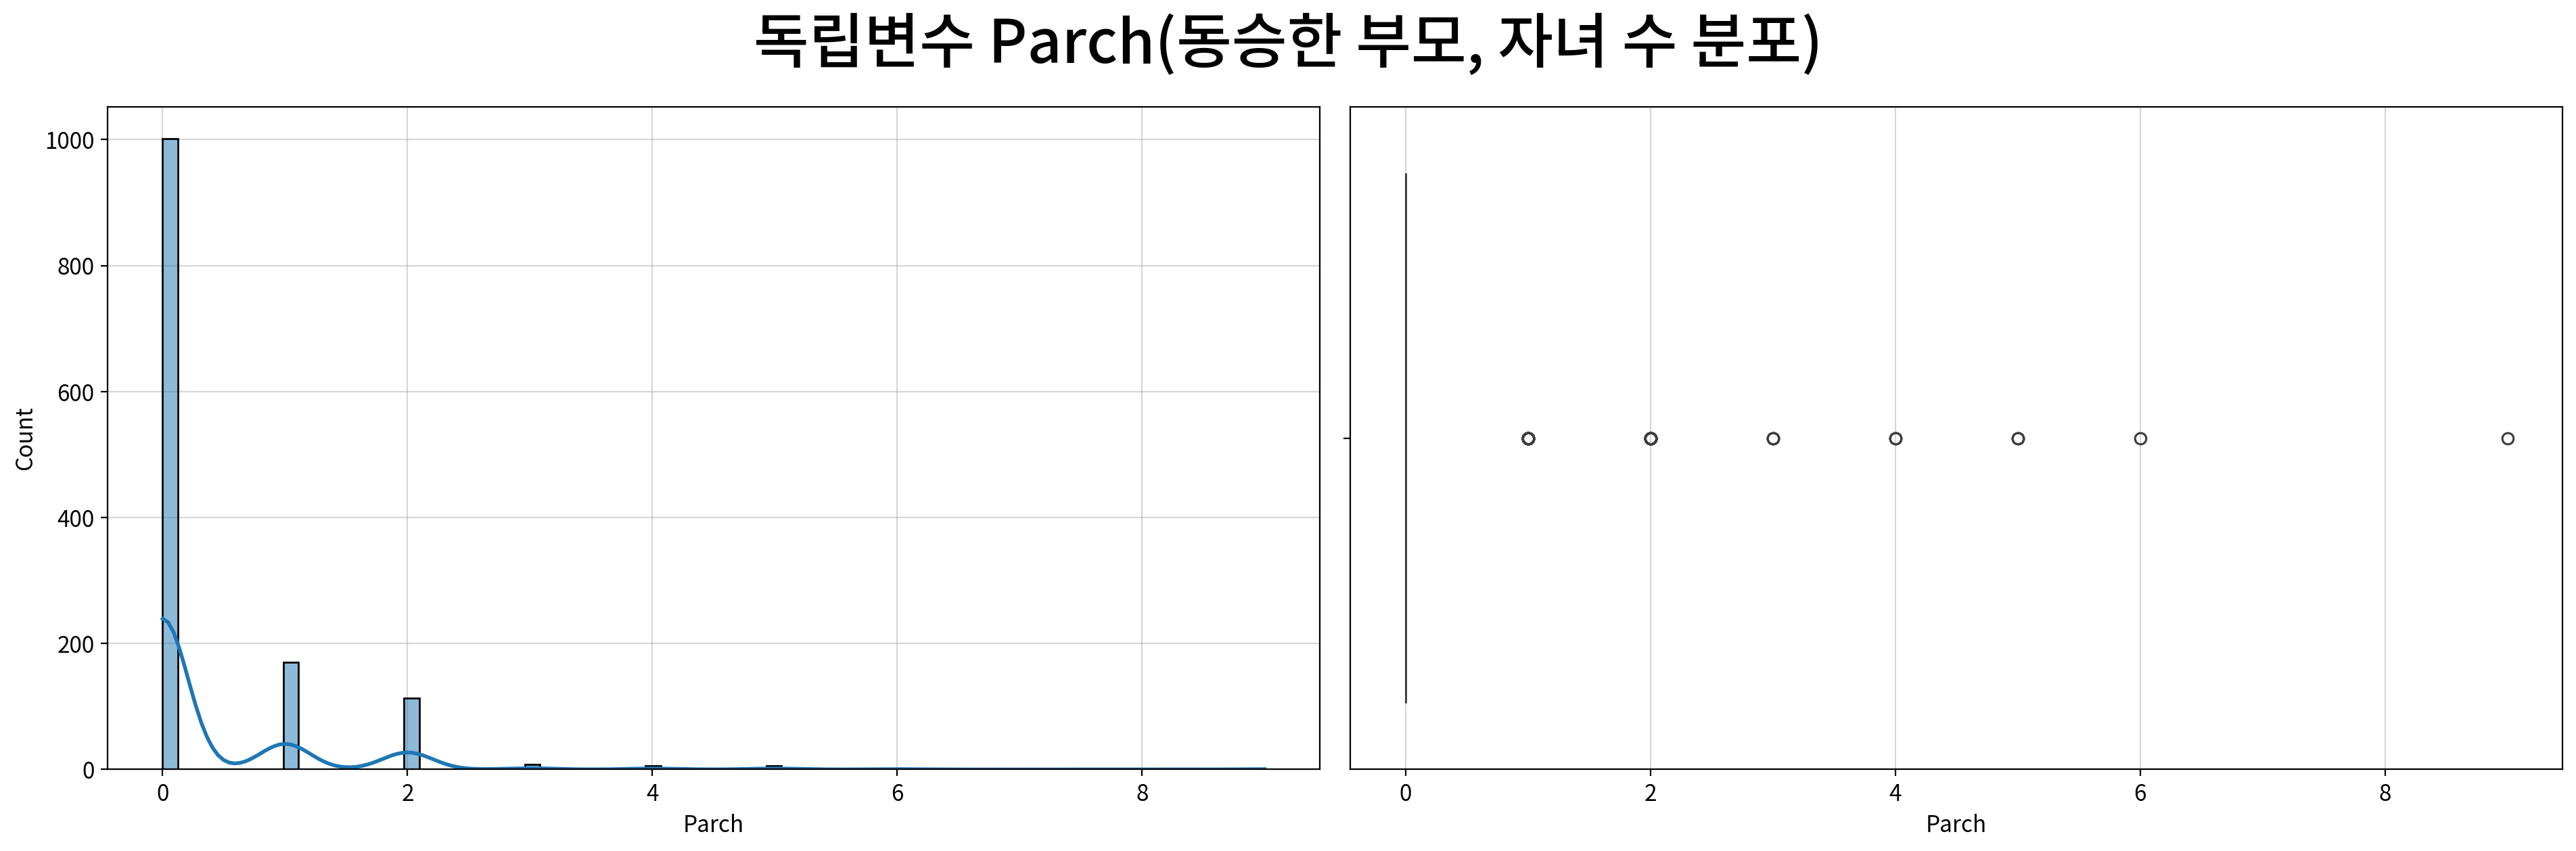

,Parch
count,1309.000
mean,0.385
std,0.866
min,0.000
25%,0.000
50%,0.000
75%,0.000
max,9.000
rel_diff,inf
rdiff_flag,large_diff


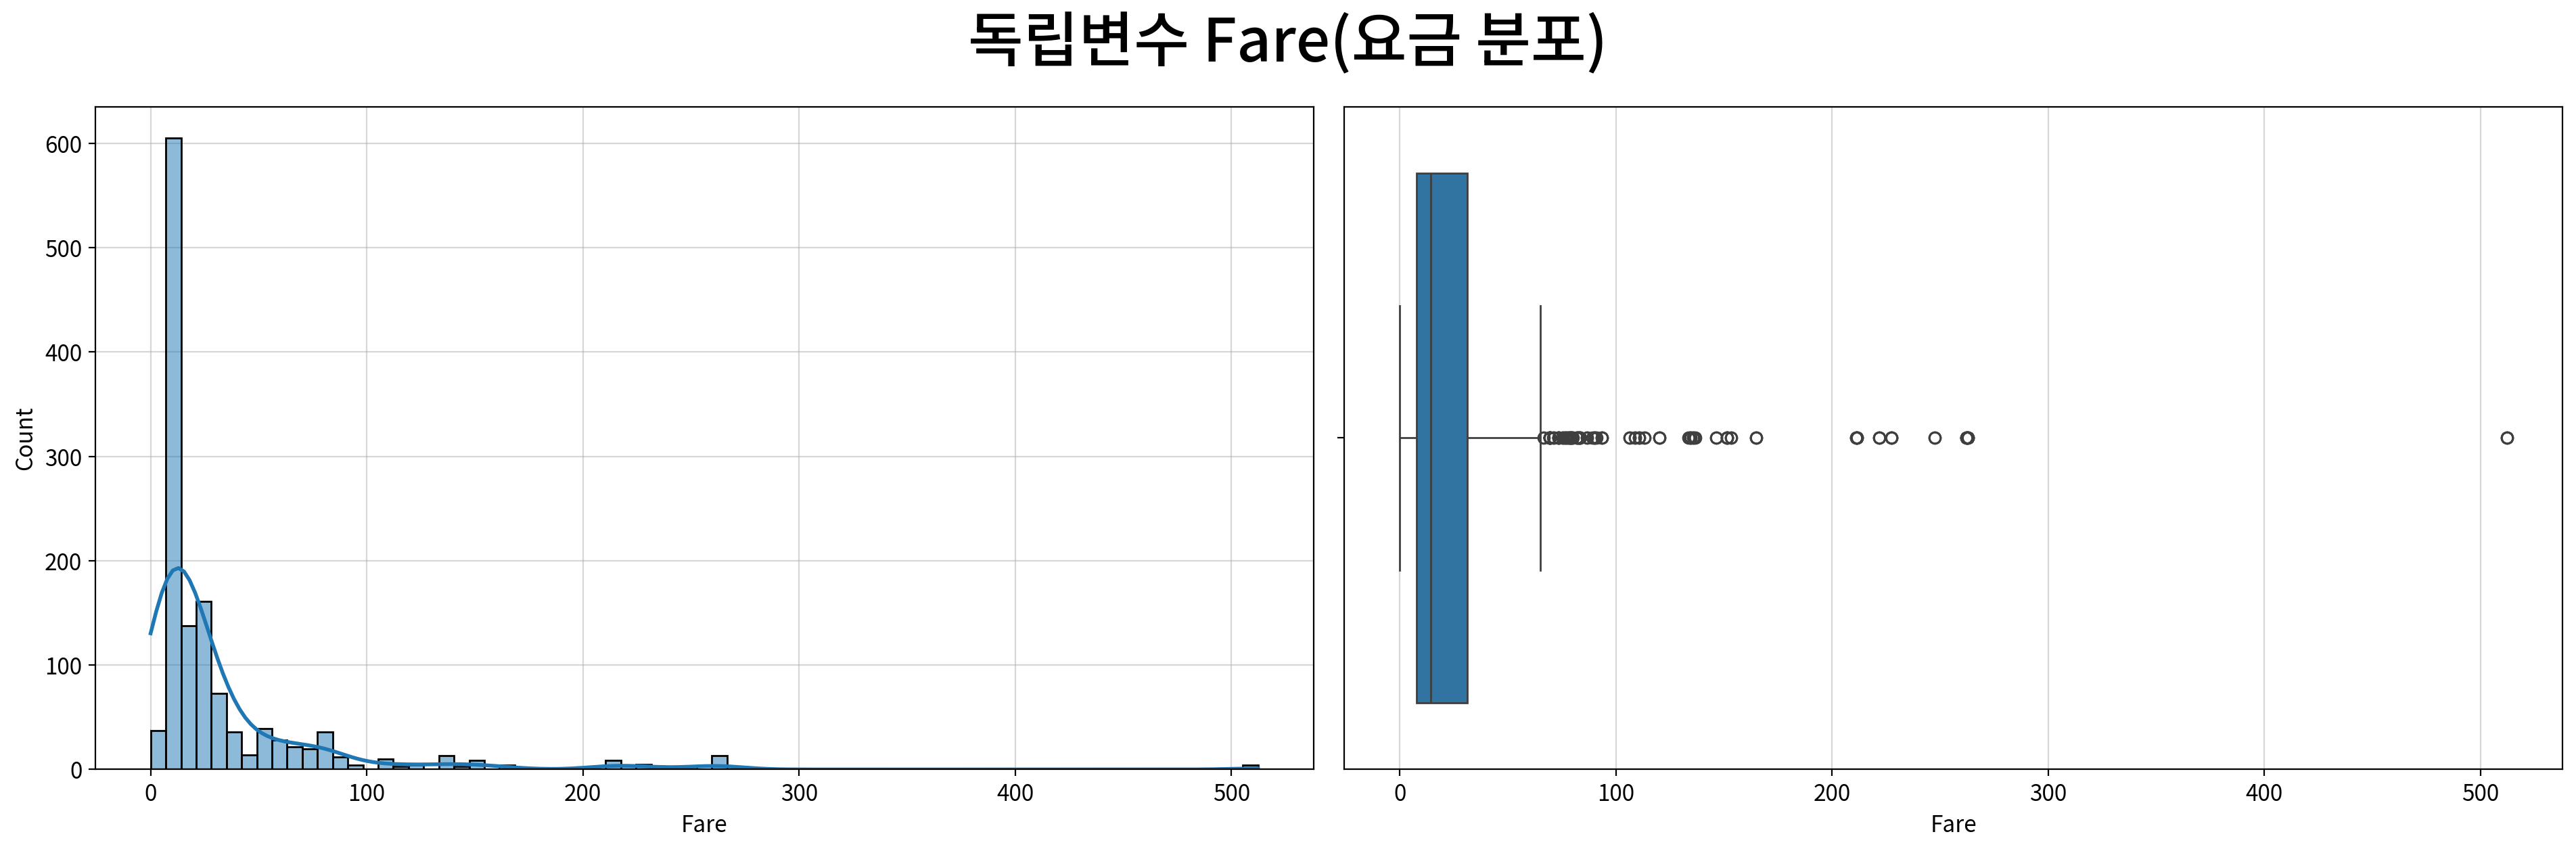

,Fare
count,1309.000
mean,33.281
std,51.741
min,0.000
25%,7.896
50%,14.454
75%,31.275
max,512.329
rel_diff,1.303
rdiff_flag,large_diff


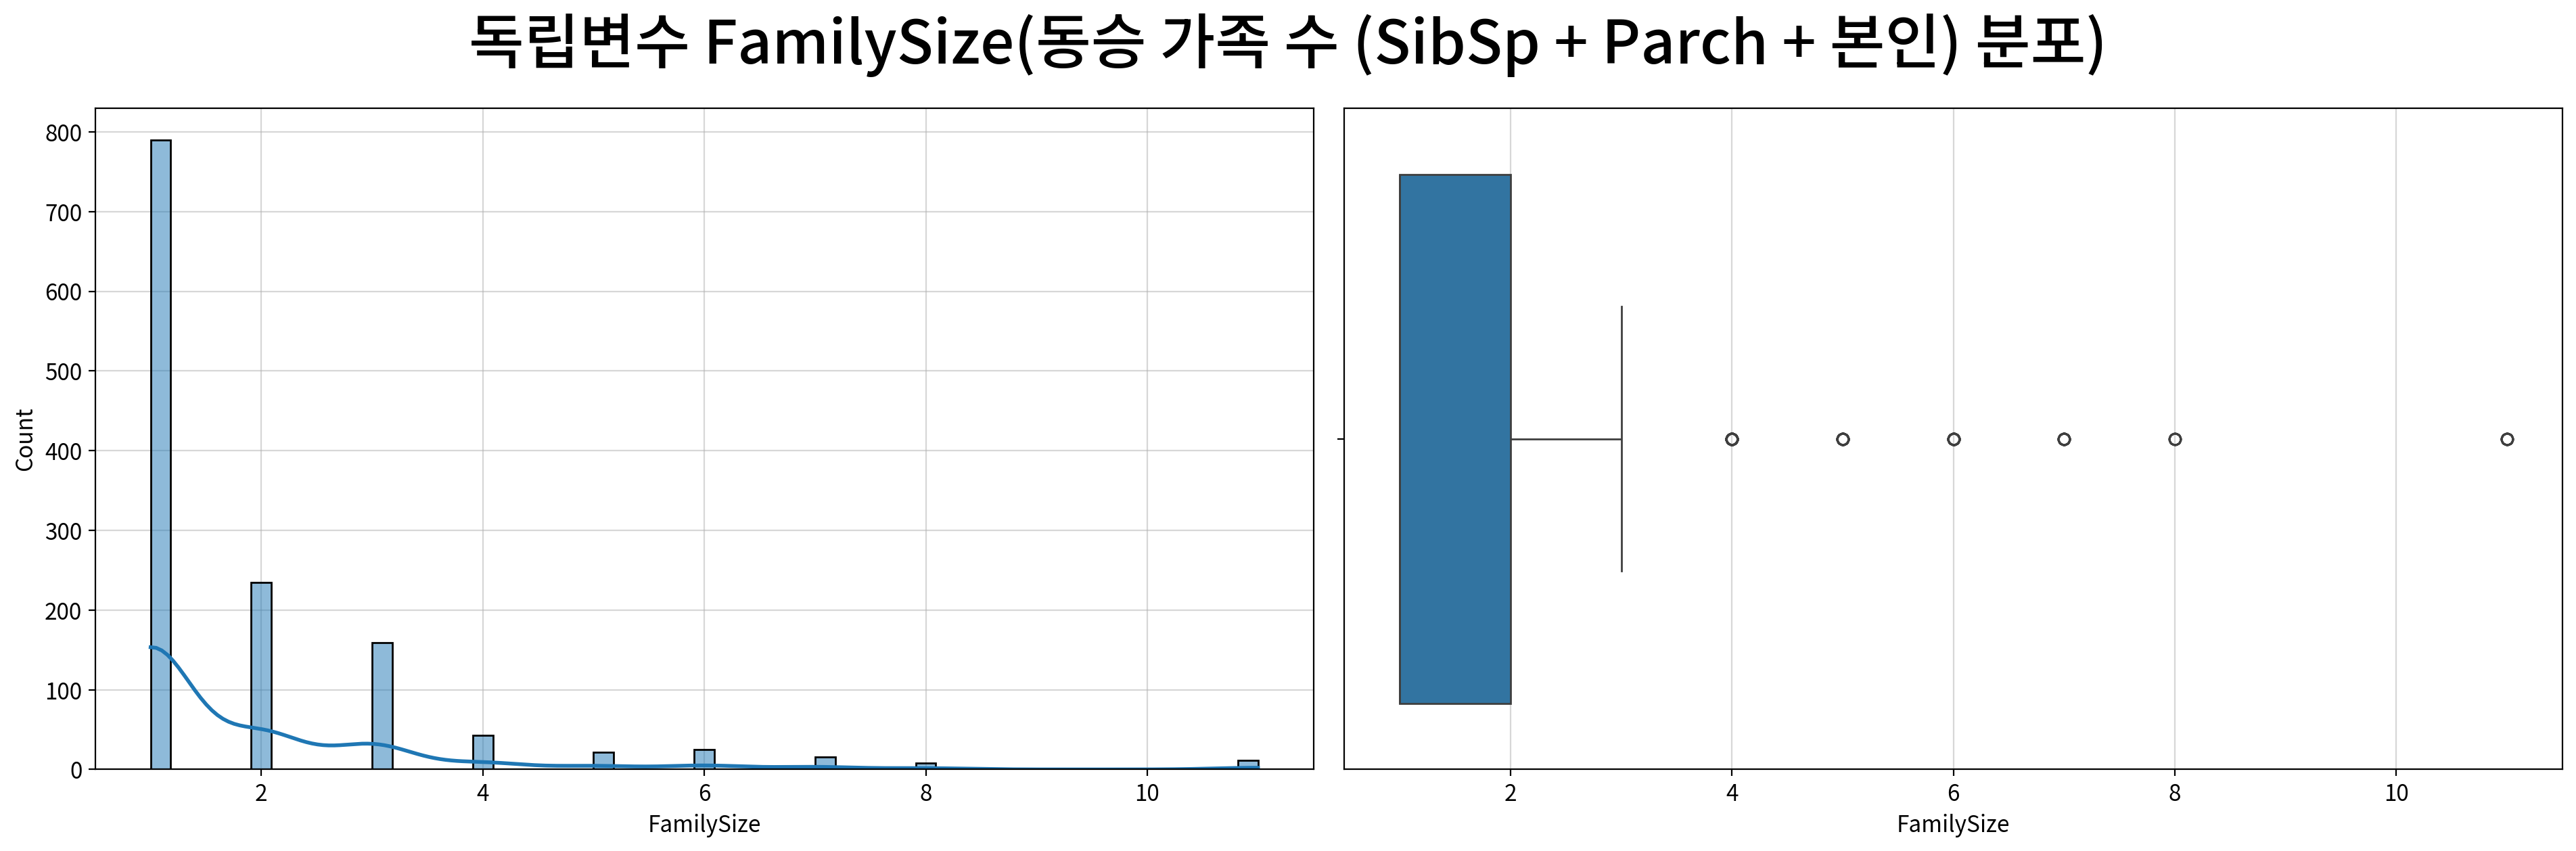

,FamilySize
count,1309.000
mean,1.884
std,1.584
min,1.000
25%,1.000
50%,1.000
75%,2.000
max,11.000
rel_diff,0.884
rdiff_flag,large_diff


In [34]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                           title=f'독립변수 {f}({column_means[f]} 분포)')
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index==f].T)

## #05. 이변량 분석
### 1. T-Test(x:연속형 독립변수 -> y:2집단 명목형 종속변수)

#### ▶ Age(나이) → Survived

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   208212.000    0.295        False  0 = 1
                    less        208212.000    0.853        False  0 ≥ 1
                    greater     208212.000    0.147        False  0 ≤ 1

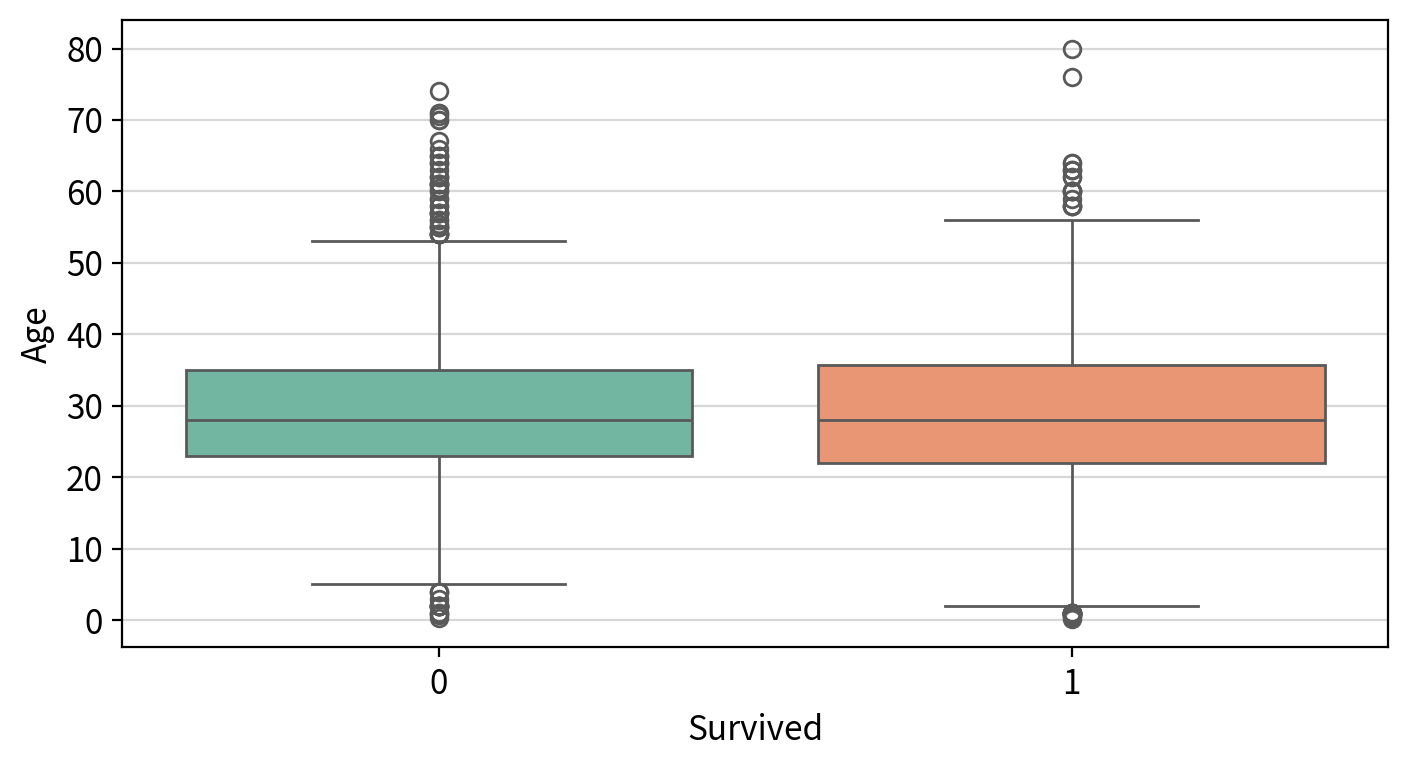

#### ▶ SibSp(동승한 형제, 배우자 수) → Survived

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   180053.500    0.000         True  0 ≠ 1
                    less        180053.500    0.000         True  0 < 1
                    greater     180053.500    1.000        False  0 ≤ 1

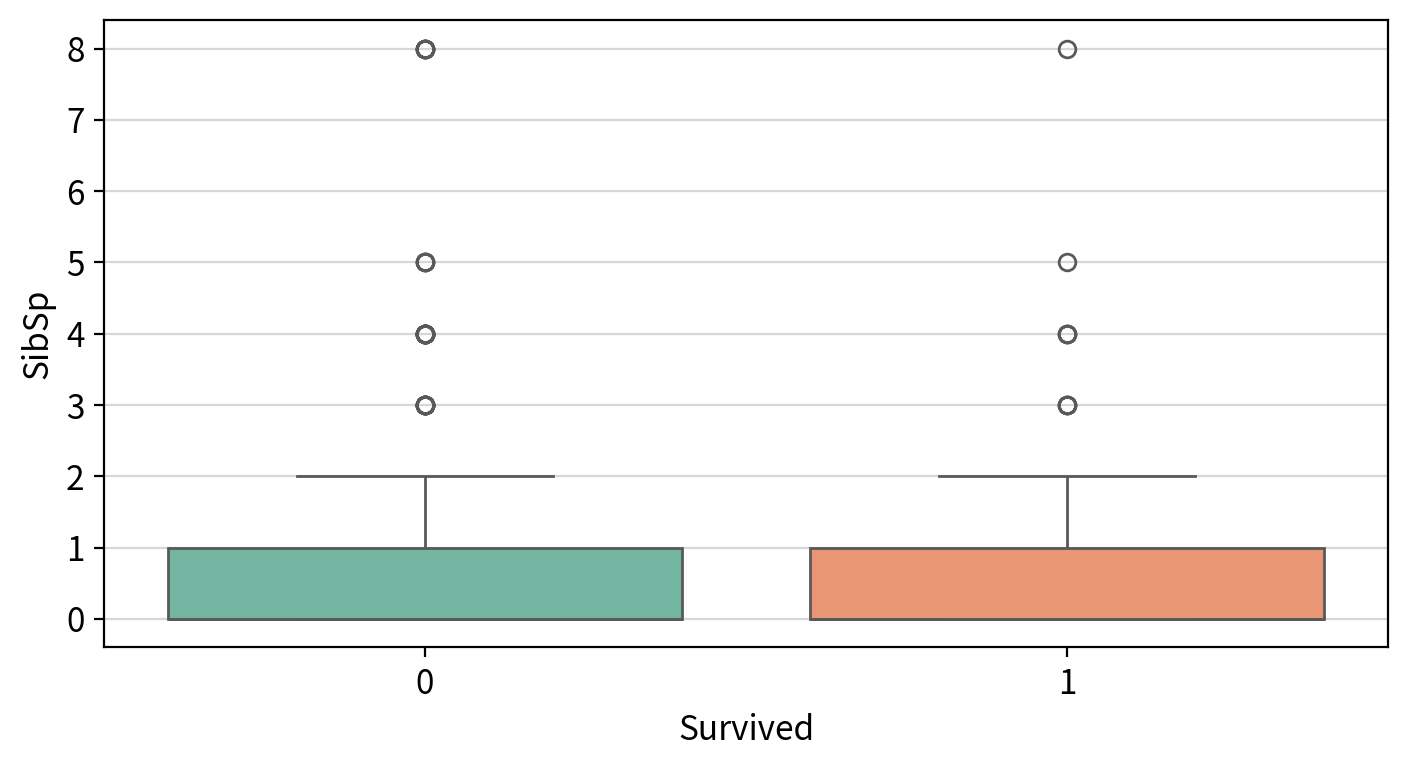

#### ▶ Parch(동승한 부모, 자녀 수) → Survived

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   171848.000    0.000         True  0 ≠ 1
                    less        171848.000    0.000         True  0 < 1
                    greater     171848.000    1.000        False  0 ≤ 1

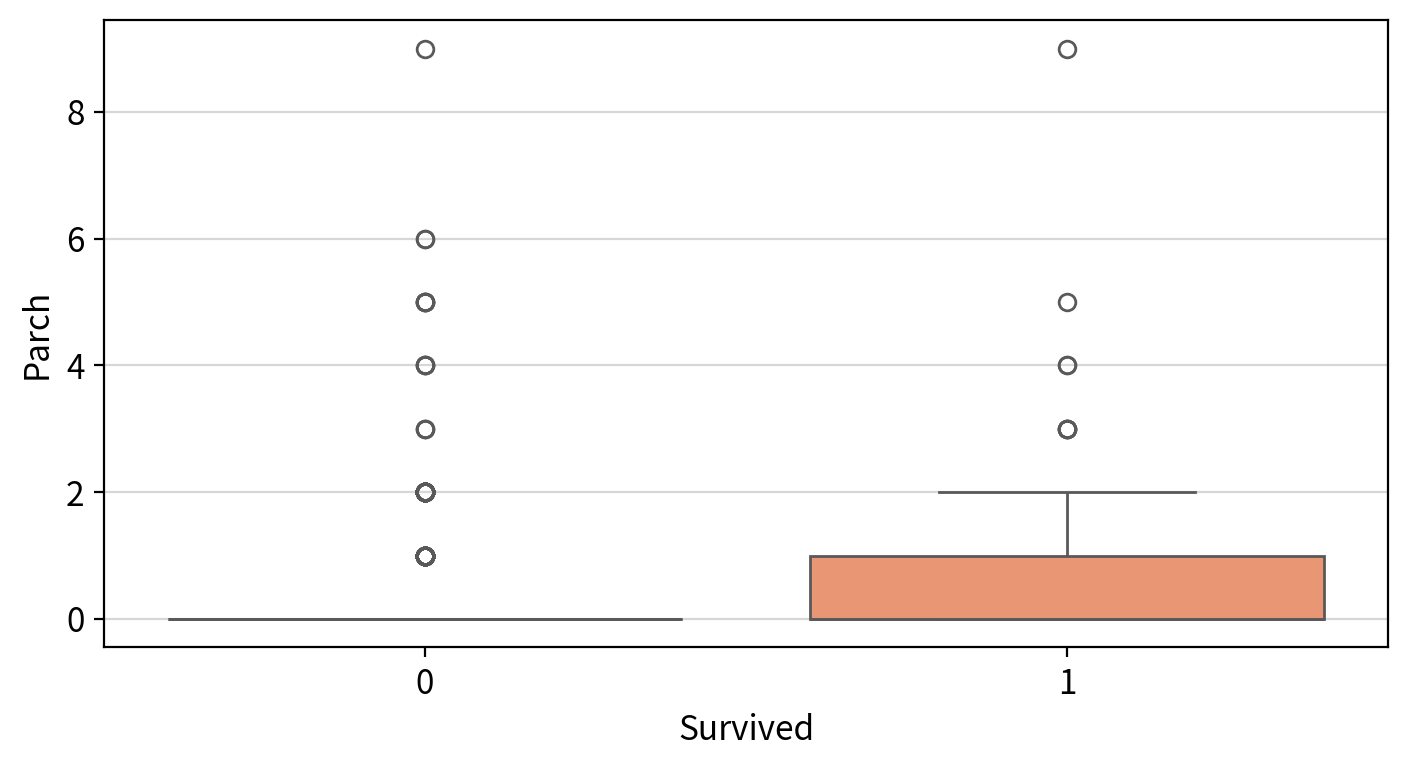

#### ▶ Fare(요금) → Survived

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   132978.000    0.000         True  0 ≠ 1
                    less        132978.000    0.000         True  0 < 1
                    greater     132978.000    1.000        False  0 ≤ 1

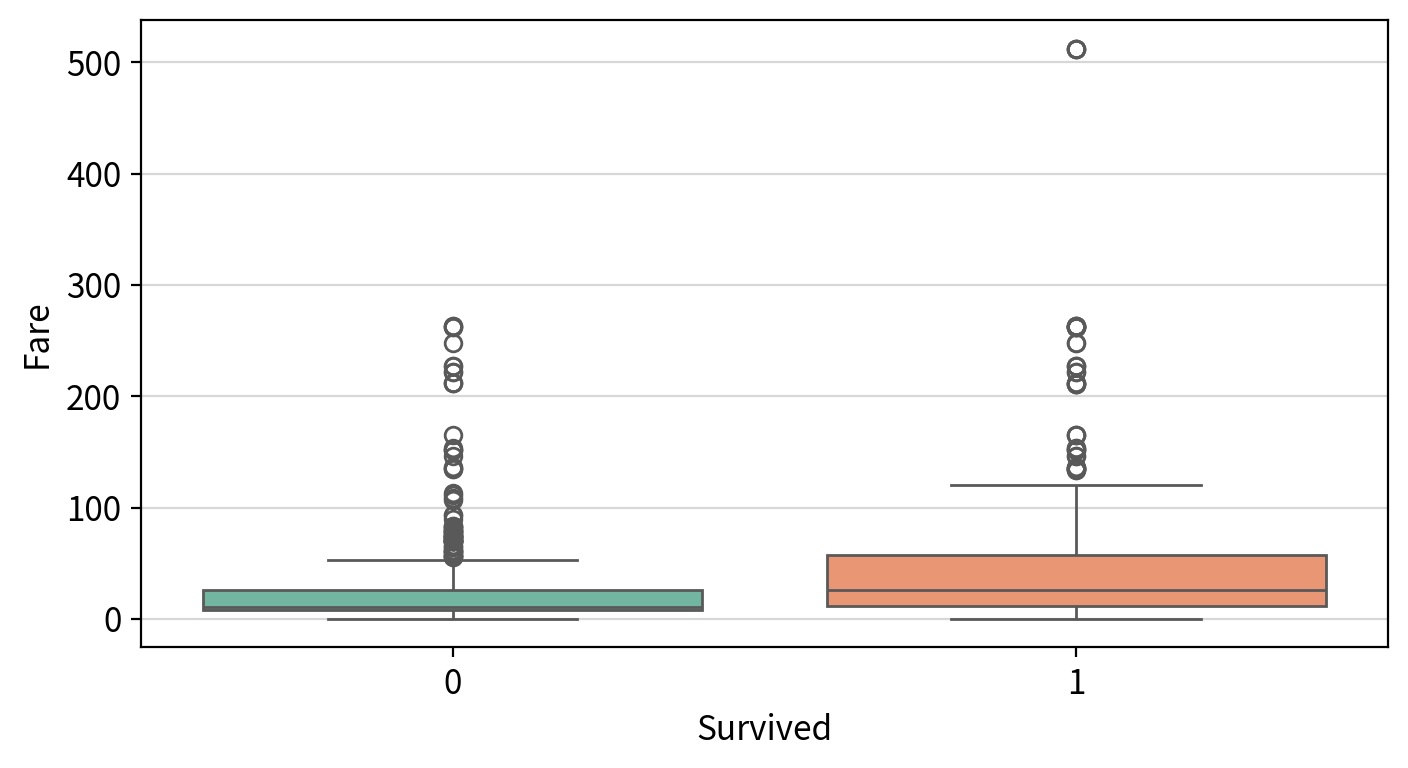

#### ▶ FamilySize(동승 가족 수 (SibSp + Parch + 본인)) → Survived

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   161466.000    0.000         True  0 ≠ 1
                    less        161466.000    0.000         True  0 < 1
                    greater     161466.000    1.000        False  0 ≤ 1

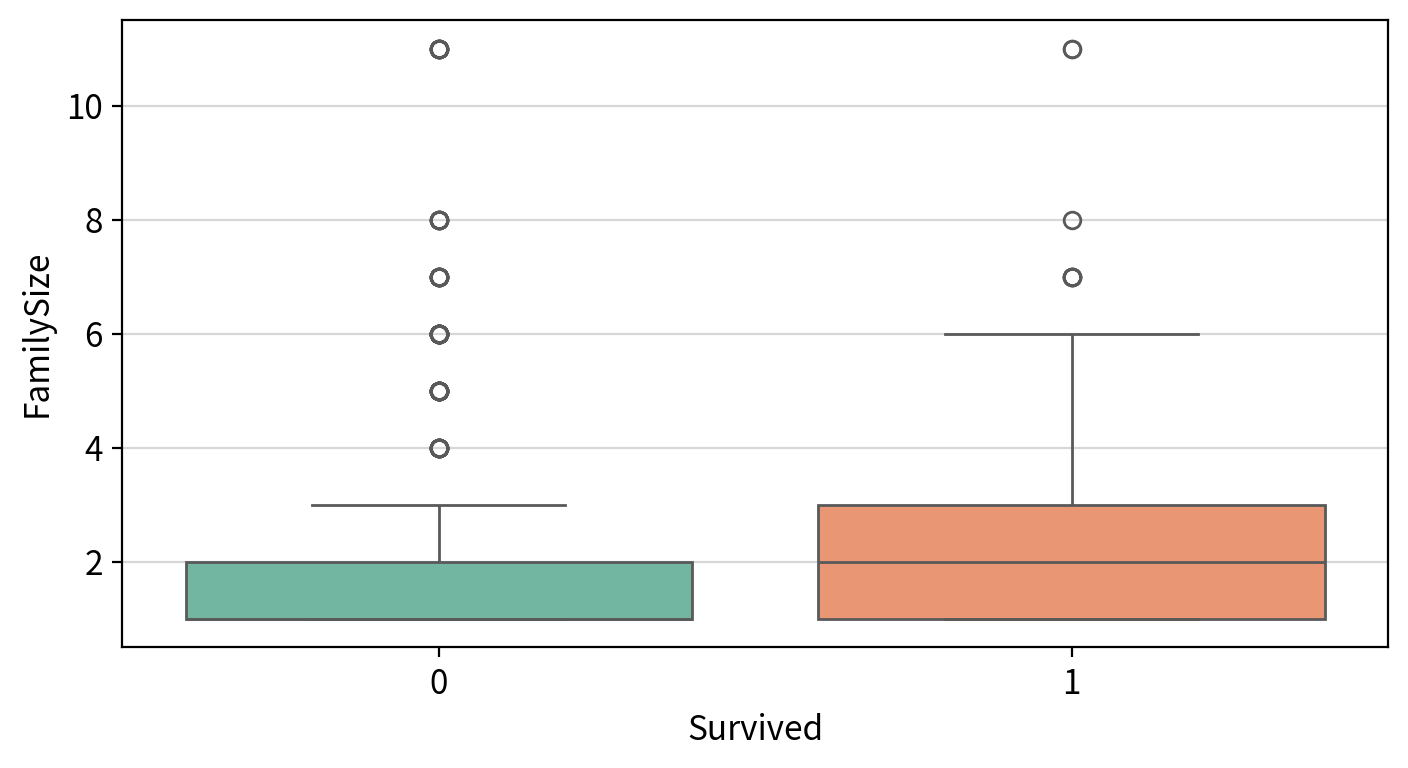

In [35]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f'#### ▶ {f}({column_means[f]}) → {target}'))

    # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
    # -> 선형회귀 때와 hue/values가 서로 뒤바뀐다. (종속변수가 집단 기준이 되므로)
    wide_df = my_prep.long2wide(df, hue=target, values=f)
    display(my_stats.test_independent(wide_df, group1=wide_df.columns[0], group2=wide_df.columns[1], plot=False))

    # 시각화: 종속변수 집단별 분포 비교
    my_plot.boxplot(data=df, x=target, y=f, hue=target, palette='Set2', width=720, height=400)

### 2. FamilySize 범주별 분포
- T검정은 두 집단의 순위 중심 위치만 비교한다.
    - 즉 '생존자 쪽이 대체로 크다/작다'까지만 말해 준다.
- 그런데 'FamilySize'는 값이 1~11인 카운트 변수라 범주별 생존율의 모양을 직접 볼 수 있다.
    - 평균 비교가 놓치는 것이 없는지 확인한다.

,사망률,생존률,인원수
FamilySize,,,
1,0.708,0.292,790
2,0.468,0.532,235
3,0.440,0.560,159
4,0.279,0.721,43
5,0.773,0.227,22
6,0.800,0.200,25
7,0.688,0.312,16
8,0.875,0.125,8
11,0.818,0.182,11


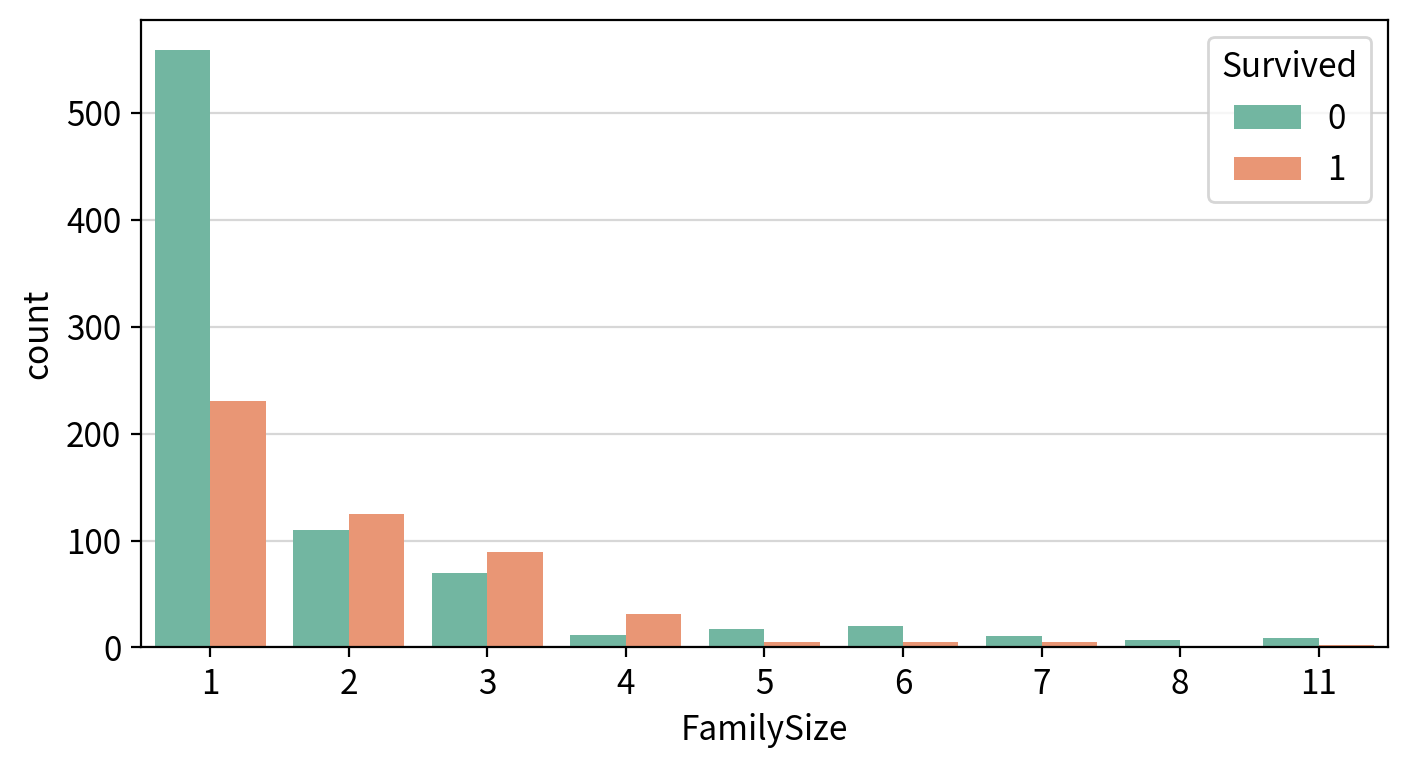

In [36]:
# 가족 규모별 생존율을 직접 계산한다.
fs_rate =df.groupby('FamilySize', observed=True)[target].value_counts(normalize=True).unstack()
fs_rate.columns = ['사망률', '생존률']
fs_rate['인원수'] = df['FamilySize'].value_counts().sort_index()
display(fs_rate)

# 시각화: 가족 규모별 생존 빈도
my_plot.countplot(data=df, x='FamilySize', hue=target, palette='Set2', width=720, height=400)

### 3. 교차분석(x:명목형 독립변수 → y: 명목형 종속변수)
- 명목형 독립변수가 있을 경우 카이제곱 독립성 검정을 수행한다.

#### ▶ Pclass(객실 등급(1=1등급, 2=2등급, 3=3등급)) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Pclass,Survived,Chi-square test of independence,91.724,2,0.000,True,0.265,Weak,104.540,True


Survived,0,1
Pclass,,
3,0.731,0.269
2,0.578,0.422
1,0.424,0.576


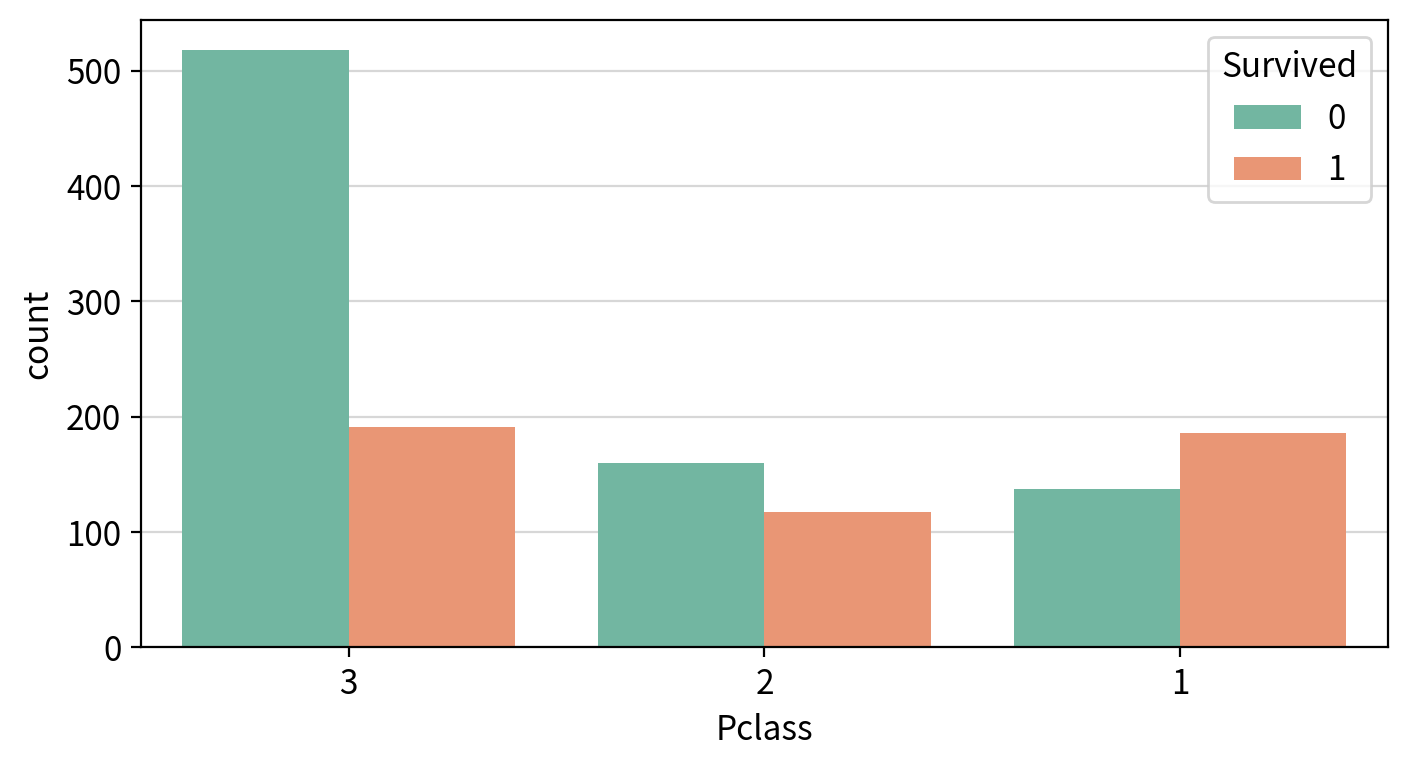

#### ▶ Sex(성별) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Sex,Survived,Chi-square test of independence,617.313,1,0.000,True,0.687,Strong,175.860,True


Survived,0,1
Sex,,
female,0.174,0.826
male,0.871,0.129


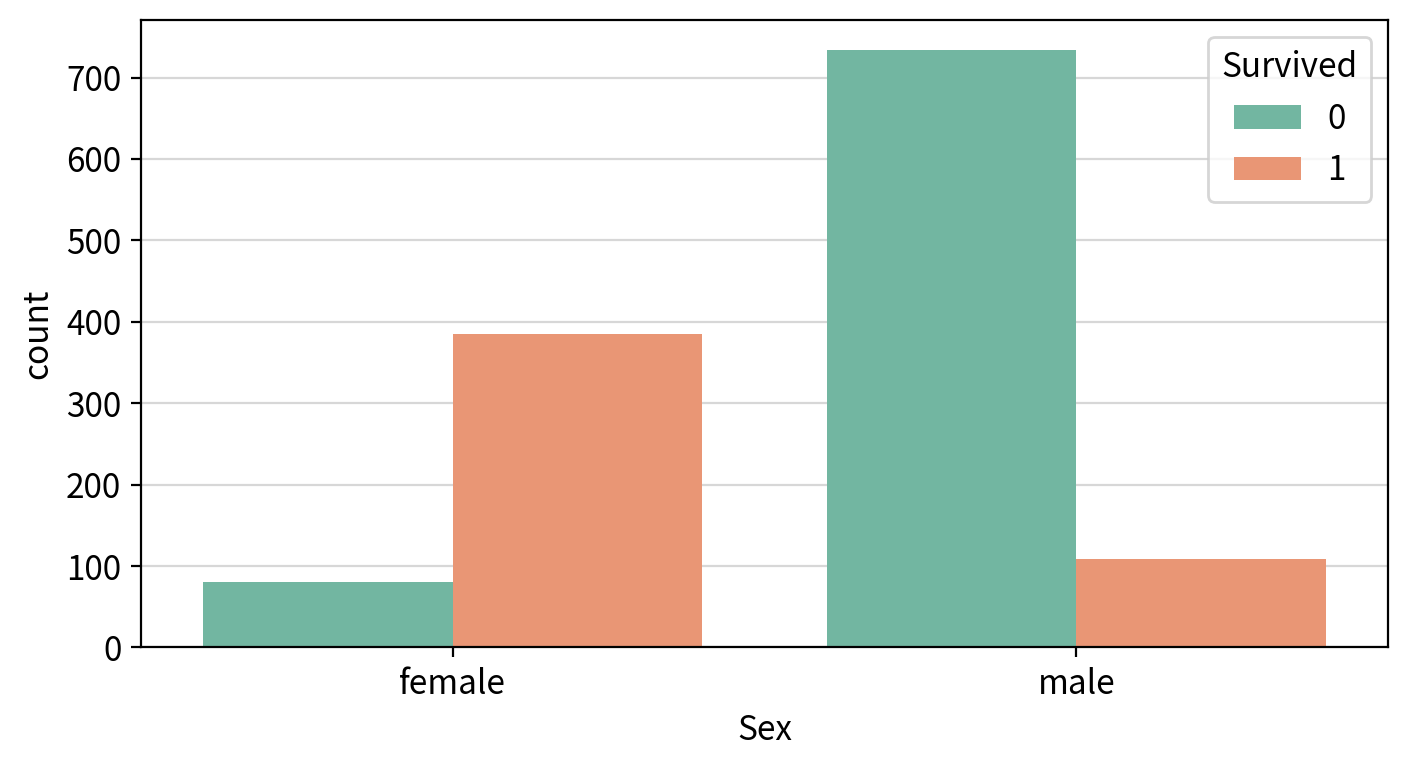

#### ▶ Embarked(탑승 항구(C=Cherbourg, Q=Queenstown, S=Southanpton)) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Embarked,Survived,Chi-square test of independence,24.194,2,0.000,True,0.136,Weak,46.420,True


Survived,0,1
Embarked,,
C,0.507,0.493
Q,0.561,0.439
S,0.665,0.335


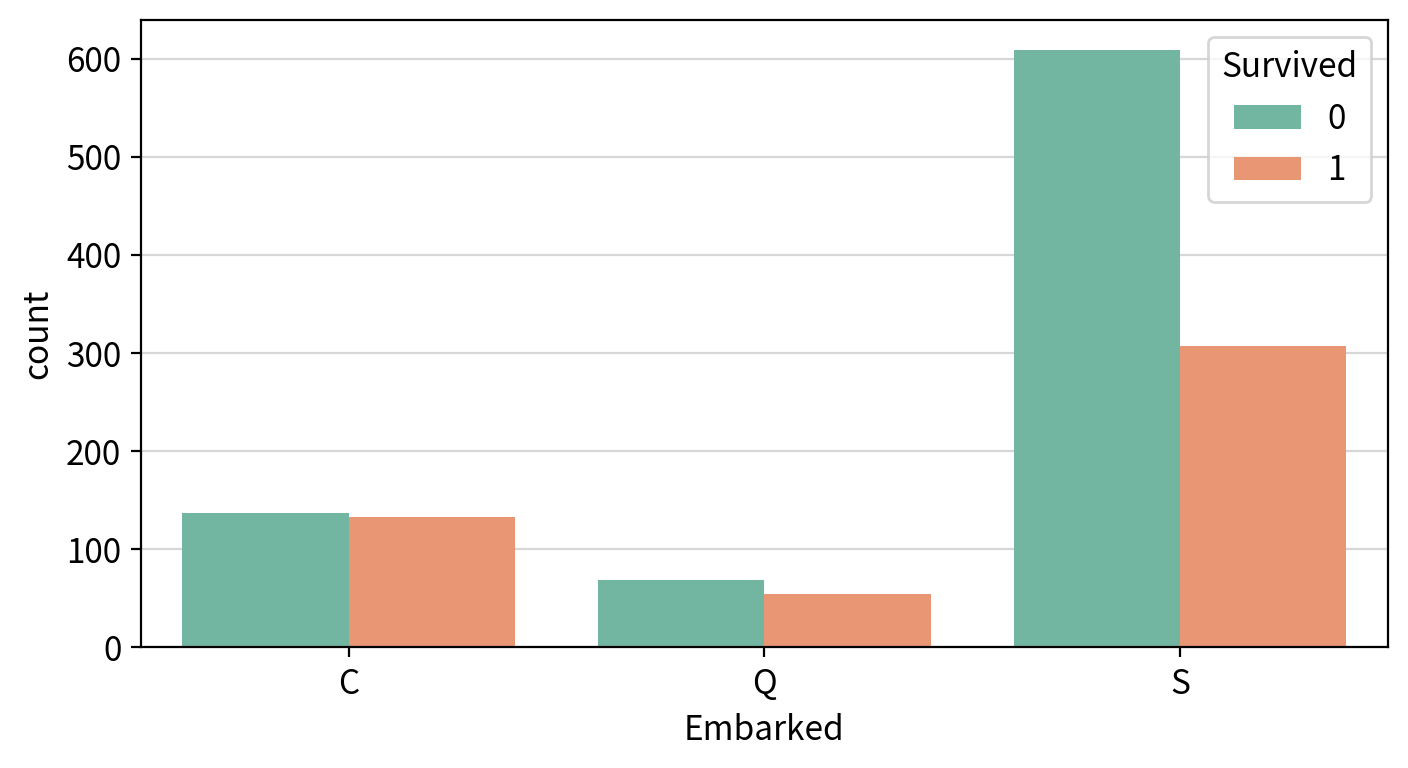

#### ▶ Title(이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)) → Survived

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Title,Survived,Chi-square test of independence,638.384,4,0.000,True,0.698,Strong,8.680,True


Survived,0,1
Title,,
Mr,0.892,0.108
Officer,0.783,0.217
Master,0.623,0.377
Miss,0.208,0.792
Mrs,0.129,0.871


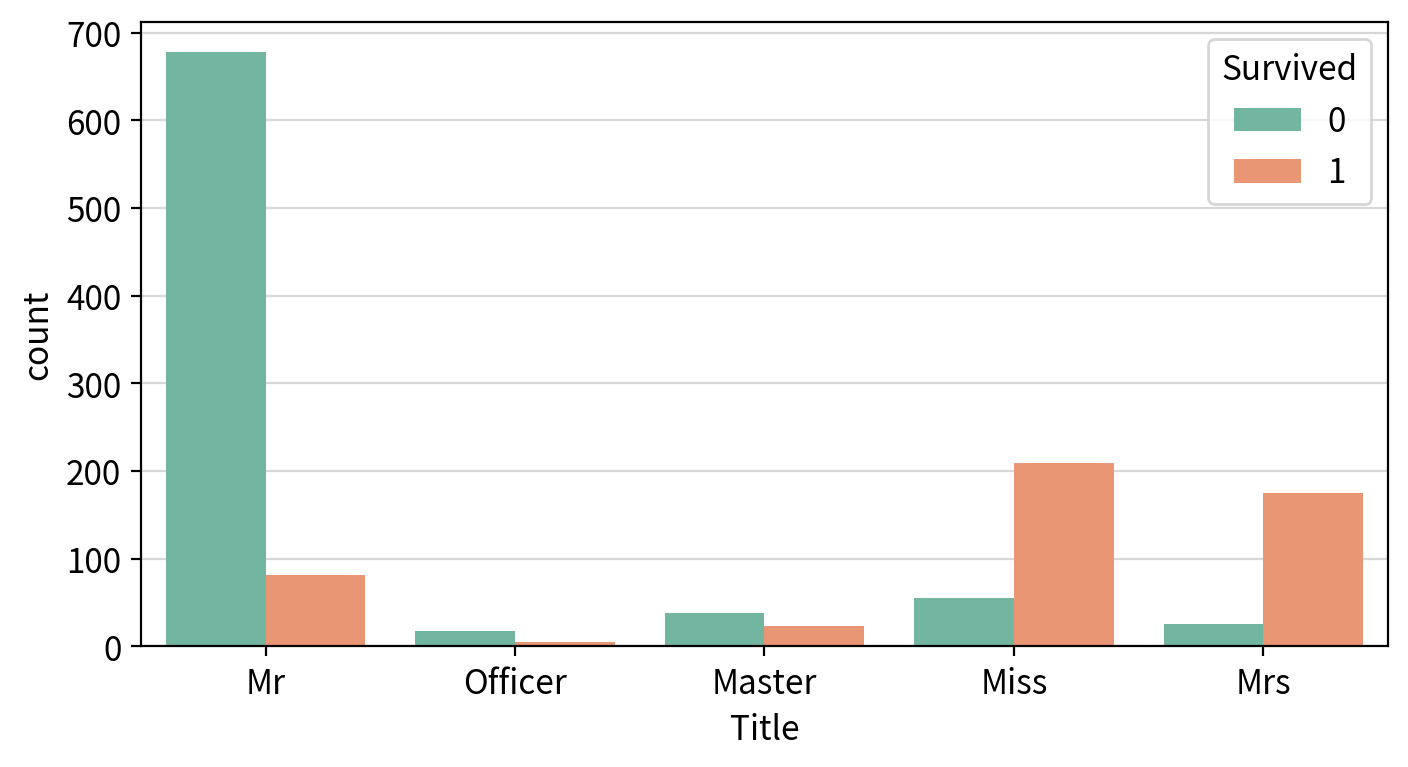

In [37]:
for n in nominal_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f'#### ▶ {n}({column_means[n]}) → {target}'))

    # 교차분석 (카이제곱 독립성 검정)
    display(my_stats.chi2_independence(df, x=n, y=target, plot=False))

    # 범주별 생존율 표
    rate = df.groupby(n, observed=True)[target].value_counts(normalize=True).unstack()
    display(rate)

    # 시각화: 범주별 생존 비율
    my_plot.countplot(data=df, x=n, hue=target, palette='Set2', width=720, height=400)


## #06. 다변량 분석
### 1. 독립변수간 상관 분석
- 연속형 독립변수끼리는 종속변수가 명목형이어도 상관분석을 그대로 쓸 수 있다.
- 파생변수 'FamilySize'가 들어왔으므로 이번 점검은 특히 중요하다.
    - 파생변수는 원본 컬럼으로 만든 것이라 원재료와 겹칠 수밖에 없기 때문이다.

In [38]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
display(my_stats.correlation_summary(corr))

# 분산팽창지수(VIF)로 한번 더 확인
display(my_stats.compute_vif(df[continuous_cols]))

c:\Users\itwill\Desktop\이하은\my work\통계\기초통계\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
c:\Users\itwill\Desktop\이하은\my work\통계\기초통계\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
c:\Users\itwill\Desktop\이하은\my work\통계\기초통계\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
c:\Users\itwill\Desktop\이하은\my work\통계\기초통계\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]


,Age,SibSp,Parch,Fare,FamilySize
Age,1.000,-0.102,-0.182,0.173,-0.135
SibSp,-0.102,1.000,0.438,0.446,0.848
Parch,-0.182,0.438,1.000,0.400,0.796
Fare,0.173,0.446,0.400,1.000,0.521
FamilySize,-0.135,0.848,0.796,0.521,1.000


,max-y,max-coef,count,columns
x,,,,
FamilySize,SibSp,0.848,2,"SibSp, Parch"
SibSp,FamilySize,0.848,1,FamilySize
Parch,FamilySize,0.796,1,FamilySize
Fare,FamilySize,0.521,0,-
Age,Parch,-0.182,0,-


c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
FamilySize,inf
Parch,inf
SibSp,inf
Fare,1.119
Age,1.099


## 연습문제 #02
□ EDA를 수행하고 다음 물음에 답하시오.

- 종속변수 Survived의 두 범주 중 더 많이 나타나는 쪽은 무엇인가요? 사망
- 그 최빈 범주가 전체에서 차지하는 비율은 얼마인가요? 0.623
- 명목형 독립변수 4종의 범주를 통틀어, 관측치가 가장 적은 범주는 무엇인가요? Officer
- 결측을 중앙값으로 채운 흔적이 히스토그램에 인공적인 봉우리로 남은 변수는 무엇인가요? Age
- 연속형 5종 중 사분위수 범위(IQR)가 0이어서 이상치 판정 자체가 무의미해진 변수는 무엇인가요? Parch
- FamilySize에서 단독 승객(가족 수 1명)이 차지하는 비율은 얼마인가요? 0.604
- 연속형 독립변수 5종에 대한 집단 비교에서, 5종 모두에 선택된 검정 방법은 무엇인가요? Mann-Whitney U
- 유의수준 5% 기준으로, 두 집단 사이에 차이가 없다고 나온 변수는 무엇인가요? Age
- 그 변수의 유의확률은 얼마인가요? 0.295
- 가족 규모별 생존율이 가장 높은 가족 수는 몇 명인가요? 4
- 그 가족 수에서의 생존율은 얼마인가요? 0.721
- 교차분석에서 Cramer's V가 가장 큰 변수는 무엇인가요? Title
- Title의 5개 범주 중 생존율이 가장 높은 범주는 무엇인가요? Mrs
- Sex로는 보이지 않던 집단으로, 성인 남성(Mr 10.8%)의 약 3배 생존율을 보인 Title 범주는 무엇인가요? Master
- 연속형 독립변수 조합 중 상관계수의 절댓값이 가장 큰 값은 얼마인가요? 0.862
- 분산팽창지수(VIF)가 무한대(inf)로 나온 변수는 몇 개인가요? 3
- 이변량 분석 결과만으로 곧바로 채택할 수 있는 변수는 몇 개인가요? 6
- 단독 비교에서는 차이가 없었지만, 제거하지 않고 보류로 두는 변수는 무엇인가요? Age
- 탐색적 분석 결과 때문에 제외된 변수는 몇 개인가요? 2